In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import synthpop as sp

warnings.filterwarnings("ignore")

needed = ["ogle_surfdens", "ogle_fields", "ogle_rates"]
missing = [name for name in needed if name not in globals()]
if missing:
    raise NameError(
        "This cell expects these notebook variables to already exist: "
        f"{missing}. Run the earlier ogle_microlensing.ipynb data-loading cells first."
    )

/opt/mambaforge3/envs/astro-synthpop/lib/python3.11/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


NameError: This cell expects these notebook variables to already exist: ['ogle_surfdens', 'ogle_fields', 'ogle_rates']. Run the earlier ogle_microlensing.ipynb data-loading cells first.

In [2]:
# ============================================================
# Brown-dwarf OGLE rerun + Figure 12 style plot in one cell
# - patches min_mass to 0.01
# - generates source and lens catalogs
# - computes OGLE microlensing rates
# - reproduces the Figure 12-style latitude comparison
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import synthpop as sp

warnings.filterwarnings("ignore")

# This notebook's Figure 12 path needs fetch_data, not ogle_utils.
try:
    import fetch_data
except ImportError as e:
    raise ImportError(
        "Could not import fetch_data. Run this cell from the synthpop-model-eval "
        "notebook/repo directory, or add that repo to your PYTHONPATH."
    ) from e


# ============================================================
# Inline microlensing functions from microlensing_calculations.py
# ============================================================

c = 3e8
G = 6.674e-11
mSun = 2e30
pctom = 3.086e16

def calc_thetaE(lmass, ldist, sdist):
    """
    Angular Einstein radius in radians.
    lmass [Msun], ldist [kpc], sdist [kpc]
    """
    return np.nan_to_num(
        np.sqrt(4 * G * mSun * lmass * (ldist**-1 - sdist**-1) / (1000 * pctom * c**2)),
        nan=0.0
    )

def calc_muRel(lmul, smul, lmub, smub):
    """
    Relative proper motion.
    Inputs are mas/yr; output is rad/day.
    """
    mu = np.sqrt((lmul - smul)**2 + (lmub - smub)**2)
    return mu * (1.0 / 1000.0) * (1.0 / 365.25) * (1.0 / 3600.0) * np.pi / 180.0

def mulens_stats(
    l,
    b,
    f_lens,
    f_src,
    field_id=None,
    outputs=None,
    nsd=False,
    roman_blue=False,
    mag_band=None,
    mag_cut=np.inf,
    f_lens_kwargs=None,
    f_src_kwargs=None,
    sa_lens=None,
    sa_src=None,
    tE_range=None,
    use_n=np.inf,
):
    if outputs is None:
        outputs = [
            "l", "b", "n_source", "n_lens", "sa_source", "sa_lens",
            "avg_tau", "avg_murel", "avg_theta",
            "eventrate_area", "eventrate_source",
            "avg_t", "avg_logt",
            "stdev_t", "stdev_logt",
            "avg_ds", "avg_dl",
            "stdev_ds", "stdev_dl", "stdev_t",
            "frac_bulge_lens", "frac_disk_lens",
            "frac_bulge_source", "frac_disk_source",
            "n_compact_obj", "frac_compact_obj", "frac_lowmass",
            "field_id", "f_src", "f_lens"
        ]
    else:
        outputs = list(outputs)

    if f_lens_kwargs is None:
        f_lens_kwargs = {}
    if f_src_kwargs is None:
        f_src_kwargs = {}

    if nsd:
        if "frac_nsd_lens" not in outputs:
            outputs += ["frac_nsd_lens", "frac_nsd_source"]
    if roman_blue:
        if "frac_det_blue" not in outputs:
            outputs += ["frac_det_blue"]

    out = {}
    out["l"] = l
    out["b"] = b

    l_cols = ["Mass", "iMass", "Dist", "pop", "mul", "mub", "phase"]
    s_cols = ["Dist", "pop", "mul", "mub"]

    if mag_band is not None:
        s_cols.append(mag_band)
    if roman_blue:
        s_cols.append("Z087")

    # Read catalogs
    if str(f_src).endswith(".csv"):
        srcs = pd.read_csv(f_src, usecols=s_cols, **f_src_kwargs)
    elif str(f_src).endswith(".h5"):
        srcs = pd.read_hdf(f_src, key="data", columns=s_cols, **f_src_kwargs)
    else:
        raise ValueError(f"Unsupported source file type: {f_src}")

    if str(f_lens).endswith(".csv"):
        lens = pd.read_csv(f_lens, usecols=l_cols, **f_lens_kwargs)
    elif str(f_lens).endswith(".h5"):
        lens = pd.read_hdf(f_lens, key="data", columns=l_cols, **f_lens_kwargs)
    else:
        raise ValueError(f"Unsupported lens file type: {f_lens}")

    # Solid angles from sidecar log files, same logic as original helper
    def get_solid_angle(logfile, supplied_sa=None):
        if supplied_sa is not None:
            return supplied_sa * ((np.pi / 180.0) ** 2)

        sv = []
        sav = 0
        with open(logfile, "r") as f:
            for line in f:
                if sav == 1:
                    sv.append(line)
                    sav = 0
                if "set solid_angle to" in line:
                    sav = 1

        row = sv[-1].split(" ")
        return float(row[-2]) * ((np.pi / 180.0) ** 2) ** int("deg^2" in row[-1])

    f_lens_param = ".".join(str(f_lens).split(".")[:-1]) + ".log"
    f_src_param = ".".join(str(f_src).split(".")[:-1]) + ".log"

    la = get_solid_angle(f_lens_param, sa_lens)
    sa = get_solid_angle(f_src_param, sa_src)

    # Optional downsampling
    if len(lens) > use_n:
        la = la * use_n / len(lens)
        lens = lens.sample(n=int(use_n), ignore_index=True)
    else:
        lens = lens.reset_index(drop=True)

    if len(srcs) > use_n:
        sa = sa * use_n / len(srcs)
        srcs = srcs.sample(n=int(use_n), ignore_index=True)
    else:
        srcs = srcs.reset_index(drop=True)

    nl = len(lens.index)
    out["n_lens"] = nl
    out["sa_source"] = sa
    out["sa_lens"] = la

    # Lens arrays
    lens_idxs = np.array(lens.index)
    lens_dists = np.array(lens["Dist"])
    lens_masses = np.array(lens["Mass"])
    lens_muls = np.array(lens["mul"])
    lens_mubs = np.array(lens["mub"])
    lens_pops = np.array(lens["pop"])
    lens_cos = (np.array(lens["phase"]) > 100).astype(int)
    lens_lowmass = (np.array(lens["iMass"]) < 0.1).astype(int)
    lens_inbulge = (lens_pops == 0.0).astype(int)

    if nsd:
        lens_innsd = (lens_pops == 2.0).astype(int)
        lens_indisk = (lens_pops >= 3.0).astype(int)
    else:
        lens_indisk = (lens_pops >= 2.0).astype(int)

    # Source selection
    if mag_band is None:
        do_srcs = srcs.index
    else:
        do_srcs = srcs[srcs[mag_band] < mag_cut].index

    do_srcs = srcs.loc[do_srcs].reset_index(drop=True)
    src_idxs = np.array(do_srcs.index)
    ns = len(src_idxs)
    out["n_source"] = ns

    src_mesh, lens_mesh = np.meshgrid(src_idxs, lens_idxs)
    src_mesh = src_mesh.flatten()
    lens_mesh = lens_mesh.flatten()

    src_dists = np.array(do_srcs["Dist"])
    src_muls = np.array(do_srcs["mul"])
    src_mubs = np.array(do_srcs["mub"])
    src_pops = np.array(do_srcs["pop"])

    if roman_blue:
        src_Z087 = (np.array(do_srcs["Z087"] < 24)).astype(int)

    src_inbulge = (src_pops == 0.0).astype(int)
    if nsd:
        src_innsd = (src_pops == 2.0).astype(int)
        src_indisk = (src_pops >= 3.0).astype(int)
    else:
        src_indisk = (src_pops >= 2.0).astype(int)

    # Valid lens-source pairs
    dist_comp = (src_dists[src_mesh] > lens_dists[lens_mesh])
    use_srcs = src_mesh[dist_comp]
    use_lens = lens_mesh[dist_comp]

    theta_e = calc_thetaE(
        lens_masses[use_lens],
        lens_dists[use_lens],
        src_dists[use_srcs]
    )
    mu_rel = calc_muRel(
        lens_muls[use_lens],
        src_muls[use_srcs],
        lens_mubs[use_lens],
        src_mubs[use_srcs]
    )
    t_e = theta_e / mu_rel

    if tE_range is not None:
        good_tes = ((t_e > tE_range[0]) & (t_e < tE_range[1]))
        use_srcs = use_srcs[good_tes]
        use_lens = use_lens[good_tes]

        theta_e = calc_thetaE(
            lens_masses[use_lens],
            lens_dists[use_lens],
            src_dists[use_srcs]
        )
        mu_rel = calc_muRel(
            lens_muls[use_lens],
            src_muls[use_srcs],
            lens_mubs[use_lens],
            src_mubs[use_srcs]
        )

    thetamu = theta_e * mu_rel
    sum_thetamu = np.sum(thetamu)

    if len(theta_e) == 0 or sum_thetamu == 0:
        raise ValueError(f"No valid matches for l={l}, b={b}")

    out["avg_t"] = np.average(theta_e / mu_rel, weights=thetamu)
    out["avg_logt"] = np.average(np.log10(theta_e / mu_rel), weights=thetamu)
    out["avg_theta"] = np.average(theta_e * 180 / np.pi * 3600 * 1000, weights=thetamu)
    out["avg_ds"] = np.average(src_dists[use_srcs], weights=thetamu)
    out["avg_dl"] = np.average(lens_dists[use_lens], weights=thetamu)
    out["avg_tau"] = np.pi * np.sum(theta_e**2) / (ns * la)
    out["avg_murel"] = np.average(
        mu_rel * (1000 * 365.25 * 3600 * 180.0 / np.pi),
        weights=thetamu
    )
    out["eventrate_area"] = sum_thetamu * 2 / la / (sa / (np.pi / 180.0) ** 2) * 365.25
    out["eventrate_source"] = sum_thetamu * 2 / la / ns * 365.25

    out["frac_bulge_lens"] = np.sum(lens_inbulge[use_lens] * thetamu) / sum_thetamu
    out["frac_disk_lens"] = np.sum(lens_indisk[use_lens] * thetamu) / sum_thetamu
    out["frac_bulge_source"] = np.sum(src_inbulge[use_srcs] * thetamu) / sum_thetamu
    out["frac_disk_source"] = np.sum(src_indisk[use_srcs] * thetamu) / sum_thetamu

    if nsd:
        out["frac_nsd_lens"] = np.sum(lens_innsd[use_lens] * thetamu) / sum_thetamu
        out["frac_nsd_source"] = np.sum(src_innsd[use_srcs] * thetamu) / sum_thetamu

    if roman_blue:
        out["frac_det_blue"] = np.sum(src_Z087[use_srcs] * thetamu) / sum_thetamu

    out["frac_compact_obj"] = np.sum(lens_cos[use_lens] * thetamu) / sum_thetamu
    out["frac_lowmass"] = np.sum(lens_lowmass[use_lens] * thetamu) / sum_thetamu
    out["n_compact_obj"] = np.sum(lens_cos)

    out["stdev_t"] = np.sqrt(np.average((theta_e / mu_rel - out["avg_t"])**2, weights=thetamu))
    out["stdev_logt"] = np.sqrt(np.average((np.log10(theta_e / mu_rel) - out["avg_logt"])**2, weights=thetamu))
    out["stdev_ds"] = np.sqrt(np.average((src_dists[use_srcs] - out["avg_ds"])**2, weights=thetamu))
    out["stdev_dl"] = np.sqrt(np.average((lens_dists[use_lens] - out["avg_dl"])**2, weights=thetamu))

    out["field_id"] = field_id
    out["f_lens"] = str(f_lens)
    out["f_src"] = str(f_src)

    return [out[k] for k in outputs], outputs


# ============================================================
# User settings
# ============================================================

BASE_CONF = Path("./synthpop/config_files/huston2025_defaults.synthpop_conf")
RUN_TAG = "min001"
NEW_MIN_MASS = 0.01

MODEL_NAME = f"Huston2025_{RUN_TAG}"
ROOT_OUT = Path("outputfiles") / f"ogle_chips_{RUN_TAG}"
SRC_OUT = ROOT_OUT / "src"
LENS_OUT = ROOT_OUT / "lens"
RATES_OUT = Path(f"mulens_rates_ogle_0tE300_{RUN_TAG}.txt")
PATCHED_CONF = Path(f"huston2025_defaults_{RUN_TAG}.synthpop_conf")
FIG_OUT = Path(f"ogle_bdep_tElim_only_{RUN_TAG}.pdf")

ulim = 10000
llim = 3000
alim = 4000

chosen_bands = [
    "Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I",
    "2MASS_J", "2MASS_H", "2MASS_Ks"
]

outputs = [
    "l", "b", "n_source", "n_lens", "sa_source", "sa_lens",
    "avg_tau", "avg_murel", "avg_theta",
    "eventrate_area", "eventrate_source",
    "avg_t", "avg_logt",
    "stdev_t", "stdev_logt",
    "avg_ds", "avg_dl",
    "stdev_ds", "stdev_dl", "stdev_t",
    "frac_bulge_lens", "frac_disk_lens",
    "frac_bulge_source", "frac_disk_source",
    "n_compact_obj", "frac_compact_obj", "frac_lowmass",
    "field_id", "f_src", "f_lens",
    "frac_nsd_lens", "frac_nsd_source",
]


# ============================================================
# Patch config: min_mass -> 0.01
# ============================================================

if not BASE_CONF.exists():
    raise FileNotFoundError(f"Could not find config file: {BASE_CONF}")

conf = json.loads(BASE_CONF.read_text())
conf["POPULATION_GENERATION"]["mass_lims"]["min_mass"] = NEW_MIN_MASS
PATCHED_CONF.write_text(json.dumps(conf, indent=2))
print(f"Patched config written to: {PATCHED_CONF}")


# ============================================================
# Load OGLE data exactly the way the notebook does
# ============================================================

ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019()
ogle_rates["RAdeg"] = ogle_fields["RAdeg"]
ogle_rates["DEdeg"] = ogle_fields["DEdeg"]

ogle_rates = ogle_rates.sort_values("GLAT").copy()
ogle_rates["in_lims"] = (
    (np.abs(ogle_rates["GLON"]) < 10)
    & (ogle_rates["GLAT"] < 5)
    & (ogle_rates["GLAT"] > -10)
)
ogle_rates["use_for_latdep"] = (
    (np.abs(ogle_rates["GLON"]) < 3)
    & (ogle_rates["Nevents"] > 1)
    & (np.abs(ogle_rates["GLAT"]) > 0.7)
)

subfs_inmap = ogle_surfdens[
    (np.abs(ogle_surfdens.GLON) < 10)
    & (ogle_surfdens.GLAT < 5)
    & (ogle_surfdens.GLAT > -10)
].copy()

print(f"{len(subfs_inmap)} chips inside the extinction-map bounds")


# ============================================================
# Make output folders
# ============================================================

SRC_OUT.mkdir(parents=True, exist_ok=True)
LENS_OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Build source/lens catalogs
# Same logic as run_ogle_catalogs_src.py and lens.py
# ============================================================

src_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 21, "remove"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": True}],
    name_for_output=MODEL_NAME,
    output_location=str(SRC_OUT),
    skip_lowmass_stars=True,
    output_file_type="h5",
)

lens_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 99, "keep"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": False}],
    name_for_output=MODEL_NAME,
    output_location=str(LENS_OUT),
    output_file_type="h5",
)

def run_catalogs(mod, fields_df, label):
    mod.init_populations()
    solang = 1e-5

    for i in fields_df.index:
        l = fields_df.loc[i, "GLON"]
        b = fields_df.loc[i, "GLAT"]

        df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
        nobj = len(df)

        if (nobj > ulim) or (nobj < llim):
            print(f"{label} rerun: idx={i}, l={l:.3f}, b={b:.3f}, N={nobj}")
            solang = solang * alim / nobj
            df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
            nobj = len(df)

        solang = solang * alim / nobj
        print(f"{label} done: idx={i}, l={l:.3f}, b={b:.3f}, N={nobj}")

print("\n=== Generating source catalogs ===")
run_catalogs(src_mod, subfs_inmap, "SRC")

print("\n=== Generating lens catalogs ===")
run_catalogs(lens_mod, subfs_inmap, "LENS")


# ============================================================
# Compute chip microlensing rates
# Same logic as calc_rates_ogle.py
# ============================================================

rows = []

for i in subfs_inmap.index:
    l = subfs_inmap.loc[i, "GLON"]
    b = subfs_inmap.loc[i, "GLAT"]

    f_lens = LENS_OUT / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"
    f_src  = SRC_OUT  / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"

    try:
        dat, _ = mulens_stats(
            l=l,
            b=b,
            f_lens=str(f_lens),
            f_src=str(f_src),
            nsd=True,
            field_id=i,
            tE_range=[0, 300],
            outputs=outputs,
        )
        rows.append(dat)
        print(
            f"RATE ok: idx={i}, l={l:.3f}, b={b:.3f}, "
            f"tau={dat[6]:.4g}, Gamma*={dat[10]:.4g}, "
            f"Gamma_area={dat[9]:.4g}, tE={dat[11]:.4g}"
        )
    except Exception as e:
        print(f"RATE fail: idx={i}, l={l:.3f}, b={b:.3f} -> {e}")
        rows.append([l, b] + [np.nan] * (len(outputs) - 2))

chip_rates = pd.DataFrame(rows, columns=outputs)
chip_rates.to_csv(RATES_OUT, index=False)
print(f"\nSaved chip-rate table to: {RATES_OUT}")


# ============================================================
# Average chip rates back onto OGLE fields
# Same logic as the notebook's Figure 12 prep
# ============================================================

fields = ogle_fields.index
sim_fields = ogle_fields[["GLON", "GLAT"]].copy()

props_list = ["eventrate_area", "eventrate_source", "avg_tau", "avg_t", "avg_logt"]

for idx in fields:
    chips = [(idx in idx_chip) for idx_chip in subfs_inmap.index]
    if np.sum(chips) > 16:
        for prop in props_list:
            sim_fields.loc[idx, prop] = np.mean(chip_rates[prop][chips])

ogle_rates_sel = ogle_rates[ogle_rates["use_for_latdep"]].copy()
sp_dat = sim_fields.loc[ogle_rates_sel.index].copy()


# ============================================================
# Figure 12 style plot
# ============================================================

def tau_fit(b):
    return 1.36 * np.exp(0.39 * (3 - np.abs(b)))

def rt_fit(b):
    return 13.4 * np.exp(0.49 * (3 - np.abs(b)))

b_pts = np.arange(-7, 7.0001, 0.1)

plt.rcParams.update({"font.size": 18})

fig = plt.figure(figsize=(12, 12))
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.12)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
gs_bottom = outer[1].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)

ax = [[None, None], [None, None], [None, None], [None, None]]
ax[0][0] = fig.add_subplot(gs_top[0, 0])
ax[1][0] = fig.add_subplot(gs_top[1, 0], sharex=ax[0][0])
ax[0][1] = fig.add_subplot(gs_top[0, 1])
ax[1][1] = fig.add_subplot(gs_top[1, 1], sharex=ax[0][1])
ax[2][0] = fig.add_subplot(gs_bottom[0, 0])
ax[3][0] = fig.add_subplot(gs_bottom[1, 0], sharex=ax[2][0])
ax[2][1] = fig.add_subplot(gs_bottom[0, 1])
ax[3][1] = fig.add_subplot(gs_bottom[1, 1], sharex=ax[2][1])

modlab = f"SP-H25 min={NEW_MIN_MASS}"
oglab = "OGLE-IV"

# Optical depth
ax[0][0].plot(sp_dat["GLAT"], sp_dat["avg_tau"] * 1e6, "o", label=modlab)
ax[0][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tau"], yerr=ogle_rates_sel["e_tau"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][0].plot(b_pts, tau_fit(b_pts), label="OGLE Fit")
ax[0][0].set_ylabel(r"$\tau$ (10$^{-6}$)")
ax[0][0].set_ylim(0, 3.5)
ax[0][0].legend(fontsize=14)

ax[1][0].errorbar(
    sp_dat["GLAT"],
    np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"]),
    yerr=ogle_rates_sel["e_tau"] / ogle_rates_sel["tau"]**2 * np.array(sp_dat["avg_tau"]) * 1e6,
    linestyle="none", marker="o", c="k"
)
ax[1][0].set_ylabel(r"$\tau_{\rm model}/\tau_{\rm OGLE}$")
ax[1][0].axhline(1, color="gray", linestyle="--")
ax[1][0].set_ylim(0.5, 2.5)

# Event rate per star
ax[0][1].plot(sp_dat["GLAT"], sp_dat["eventrate_source"] * 1e6, "o", label=modlab)
ax[0][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam"], yerr=ogle_rates_sel["e_gam"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][1].plot(b_pts, rt_fit(b_pts), label="OGLE Fit")
ax[0][1].set_ylabel(r"$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)")
ax[0][1].set_ylim(0, 35)

ax[1][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"]),
    yerr=ogle_rates_sel["e_gam"] * np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][1].set_ylabel(r"$\Gamma_{*,\rm model}/\Gamma_{*,\rm OGLE}$")
ax[1][1].axhline(1, color="gray", linestyle="--")
ax[1][1].set_ylim(0.5, 2.5)

# Event rate per area
ax[2][0].plot(sp_dat["GLAT"], sp_dat["eventrate_area"], "o", label=modlab)
ax[2][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam-deg2"], yerr=ogle_rates_sel["e_gam-deg2"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][0].set_ylabel(r"$\Gamma$ (deg$^{-2}$ yr$^{-1}$)")
ax[3][0].set_xlabel("b (deg.)")

ax[3][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_area"]) / ogle_rates_sel["gam-deg2"],
    yerr=ogle_rates_sel["e_gam-deg2"] * np.array(sp_dat["eventrate_area"]) / ogle_rates_sel["gam-deg2"]**2,
    linestyle="none", marker="o", c="k"
)
ax[3][0].set_ylabel(r"$\Gamma_{\rm model}/\Gamma_{\rm OGLE}$")
ax[3][0].axhline(1, color="gray", linestyle="--")
ax[3][0].set_ylim(0.5, 2.8)

# Mean timescale
ax[2][1].plot(sp_dat["GLAT"], sp_dat["avg_t"], "o", label=modlab)
ax[2][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tE-mean"], yerr=ogle_rates_sel["e_tE-mean"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][1].set_ylabel(r"$\overline{t_E}$ (days)")
ax[3][1].set_xlabel("b (deg.)")

ax[3][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_t"]) / ogle_rates_sel["tE-mean"],
    yerr=ogle_rates_sel["e_tE-mean"] * np.array(sp_dat["avg_t"]) / ogle_rates_sel["tE-mean"]**2,
    linestyle="none", marker="o", c="k"
)
ax[3][1].set_ylabel(r"$\overline{t_E}_{\rm model}/\overline{t_E}_{\rm OGLE}$")
ax[3][1].axhline(1, color="gray", linestyle="--")
ax[3][1].set_ylim(0.5, 1.5)

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved Figure 12-style plot to: {FIG_OUT}")


# ============================================================
# Same weighted summary ratios as the notebook
# ============================================================

def weighted_ratio(model_vals, obs_vals, obs_errs):
    ratio = np.array(model_vals) / np.array(obs_vals)
    ratio_err = np.array(obs_errs) * np.array(model_vals) / np.array(obs_vals)**2
    return np.average(ratio[:-1], weights=1 / ratio_err[:-1]**2)

print("\nWeighted mean ratios (same style as notebook cells 18-21):")
print("eventrate_area   =", weighted_ratio(sp_dat["eventrate_area"],   ogle_rates_sel["gam-deg2"], ogle_rates_sel["e_gam-deg2"]))
print("eventrate_source =", weighted_ratio(sp_dat["eventrate_source"], ogle_rates_sel["gam"],      ogle_rates_sel["e_gam"]))
print("avg_tau          =", weighted_ratio(sp_dat["avg_tau"],          ogle_rates_sel["tau"],      ogle_rates_sel["e_tau"]))
print("avg_t            =", weighted_ratio(sp_dat["avg_t"],            ogle_rates_sel["tE-mean"],  ogle_rates_sel["e_tE-mean"]))

display(chip_rates.head())
display(sp_dat.head())

ImportError: Could not import fetch_data. Run this cell from the synthpop-model-eval notebook/repo directory, or add that repo to your PYTHONPATH.

In [2]:
BASE_CONF = Path("./synthpop/config_files/huston2025_defaults.synthpop_conf")


In [5]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import synthpop as sp

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Sanity checks: these should already exist from the notebook
# ------------------------------------------------------------
if "fetch_data" not in globals():
    raise NameError("fetch_data is not in memory. Run the notebook import cells first.")
if "microlensing_calculations" not in globals():
    raise NameError("microlensing_calculations is not in memory. Run the notebook import cells first.")

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
BASE_CONF = Path("./synthpop/config_files/huston2025_defaults.synthpop_conf")
RUN_TAG = "min001"
NEW_MIN_MASS = 0.01

MODEL_NAME = f"Huston2025_{RUN_TAG}"
ROOT_OUT = Path("outputfiles") / f"ogle_chips_{RUN_TAG}"
SRC_OUT = ROOT_OUT / "src"
LENS_OUT = ROOT_OUT / "lens"
RATES_OUT = Path(f"mulens_rates_ogle_0tE300_{RUN_TAG}.txt")
PATCHED_CONF = Path(f"huston2025_defaults_{RUN_TAG}.synthpop_conf")
FIG_OUT = Path(f"ogle_bdep_tElim_only_{RUN_TAG}.pdf")

BASELINE_RATES = Path("mulens_rates_ogle_0tE300.txt")

ulim = 10000
llim = 3000
alim = 4000

chosen_bands = [
    "Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I",
    "2MASS_J", "2MASS_H", "2MASS_Ks"
]

# ------------------------------------------------------------
# Patch config: min_mass -> 0.01
# ------------------------------------------------------------
if not BASE_CONF.exists():
    raise FileNotFoundError(f"Could not find {BASE_CONF}")

conf = json.loads(BASE_CONF.read_text())
conf["POPULATION_GENERATION"]["mass_lims"]["min_mass"] = NEW_MIN_MASS
PATCHED_CONF.write_text(json.dumps(conf, indent=2))
print(f"Patched config written to: {PATCHED_CONF}")

# ------------------------------------------------------------
# Load OGLE tables exactly as in the notebook
# ------------------------------------------------------------
ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019()
ogle_rates = ogle_rates.copy()
ogle_fields = ogle_fields.copy()
ogle_surfdens = ogle_surfdens.copy()

ogle_rates["RAdeg"] = ogle_fields["RAdeg"]
ogle_rates["DEdeg"] = ogle_fields["DEdeg"]

ogle_rates.sort_values("GLAT", inplace=True)
ogle_rates["in_lims"] = (
    (np.abs(ogle_rates["GLON"]) < 10)
    & (ogle_rates["GLAT"] < 5)
    & (ogle_rates["GLAT"] > -10)
)
ogle_rates["use_for_latdep"] = (
    (np.abs(ogle_rates["GLON"]) < 3)
    & (ogle_rates["Nevents"] > 1)
    & (np.abs(ogle_rates["GLAT"]) > 0.7)
)

subfs_inmap = ogle_surfdens[
    (np.abs(ogle_surfdens.GLON) < 10)
    & (ogle_surfdens.GLAT < 5)
    & (ogle_surfdens.GLAT > -10)
].copy()

print(f"{len(subfs_inmap)} chips inside the extinction-map region")

# ------------------------------------------------------------
# Make output folders
# ------------------------------------------------------------
SRC_OUT.mkdir(parents=True, exist_ok=True)
LENS_OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Build source and lens models
# Mirrors run_ogle_catalogs_src.py / run_ogle_catalogs_lens.py
# ------------------------------------------------------------
src_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 21, "remove"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": True}],
    name_for_output=MODEL_NAME,
    output_location=str(SRC_OUT),
    skip_lowmass_stars=True,
    output_file_type="h5",
)

lens_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 99, "keep"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": False}],
    name_for_output=MODEL_NAME,
    output_location=str(LENS_OUT),
    output_file_type="h5",
)

def run_catalogs(mod, fields_df, label):
    mod.init_populations()
    solang = 1e-5

    for i in fields_df.index:
        l = fields_df.loc[i, "GLON"]
        b = fields_df.loc[i, "GLAT"]

        df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
        leng = len(df)

        if leng > ulim or leng < llim:
            print(f"{label} rerun: idx={i}, l={l:.3f}, b={b:.3f}, N={leng}")
            solang = solang * alim / leng
            df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
            leng = len(df)

        solang = solang * alim / leng
        print(f"{label} done: idx={i}, l={l:.3f}, b={b:.3f}, N={leng}")

print("\n=== Generating source catalogs ===")
run_catalogs(src_mod, subfs_inmap, "SRC")

print("\n=== Generating lens catalogs ===")
run_catalogs(lens_mod, subfs_inmap, "LENS")

# ------------------------------------------------------------
# Compute microlensing rates
# Mirrors calc_rates_ogle.py
# ------------------------------------------------------------
chip_rows = []

for i in subfs_inmap.index:
    l = subfs_inmap.loc[i, "GLON"]
    b = subfs_inmap.loc[i, "GLAT"]

    f_lens = LENS_OUT / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"
    f_src = SRC_OUT / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"

    try:
        dat, output_cols = microlensing_calculations.mulens_stats(
            l, b,
            str(f_lens),
            str(f_src),
            nsd=True,
            field_id=i,
            tE_range=[0, 300]
        )
        chip_rows.append(dat)
        print(f"RATE ok: idx={i}, l={l:.3f}, b={b:.3f}")
    except Exception as e:
        print(f"RATE fail: idx={i}, l={l:.3f}, b={b:.3f} -> {e}")
        # preserve output width from the standard calc_rates_ogle.py behavior
        if "output_cols" in locals():
            chip_rows.append([l, b] + list(np.repeat(np.nan, len(output_cols) - 2)))
        else:
            raise

chip_rates = pd.DataFrame(chip_rows, columns=output_cols)
chip_rates.to_csv(RATES_OUT, index=False)
print(f"\nSaved chip rates to: {RATES_OUT}")

# ------------------------------------------------------------
# Average chip rates back onto OGLE fields
# Same logic as the notebook
# ------------------------------------------------------------
fields = ogle_fields.index
sim_fields = ogle_fields[["GLON", "GLAT"]].copy()
props_list = ["eventrate_area", "eventrate_source", "avg_tau", "avg_t", "avg_logt"]

for idx in fields:
    chips = [(idx in idx_chip) for idx_chip in subfs_inmap.index]
    if np.sum(chips) > 16:
        for prop in props_list:
            sim_fields.loc[idx, prop] = np.mean(chip_rates.loc[chips, prop])

ogle_rates_sel = ogle_rates[ogle_rates["use_for_latdep"]].copy()
sp_dat = sim_fields.loc[ogle_rates_sel.index].copy()

# ------------------------------------------------------------
# Figure 12 style plot
# ------------------------------------------------------------
b_pts = np.arange(-7, 7.0001, 0.1)

def tau_fit(b):
    return 1.36 * np.exp(0.39 * (3 - np.abs(b)))

def rt_fit(b):
    return 13.4 * np.exp(0.49 * (3 - np.abs(b)))

plt.rcParams.update({"font.size": 18})

fig = plt.figure(figsize=(12, 12))
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.12)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
gs_bottom = outer[1].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)

ax = [[None, None], [None, None], [None, None], [None, None]]
ax[0][0] = fig.add_subplot(gs_top[0, 0])
ax[1][0] = fig.add_subplot(gs_top[1, 0], sharex=ax[0][0])
ax[0][1] = fig.add_subplot(gs_top[0, 1])
ax[1][1] = fig.add_subplot(gs_top[1, 1], sharex=ax[0][1])
ax[2][0] = fig.add_subplot(gs_bottom[0, 0])
ax[3][0] = fig.add_subplot(gs_bottom[1, 0], sharex=ax[2][0])
ax[2][1] = fig.add_subplot(gs_bottom[0, 1])
ax[3][1] = fig.add_subplot(gs_bottom[1, 1], sharex=ax[2][1])

modlab = f"SP-H25 min={NEW_MIN_MASS}"
oglab = "OGLE-IV"

# Optical depth
ax[0][0].plot(sp_dat["GLAT"], sp_dat["avg_tau"] * 1e6, "o", label=modlab)
ax[0][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tau"], yerr=ogle_rates_sel["e_tau"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][0].plot(b_pts, tau_fit(b_pts), label="OGLE Fit")
ax[0][0].set_ylabel(r"$\tau$ (10$^{-6}$)")
ax[0][0].set_ylim(0, 3.5)
ax[0][0].legend(fontsize=14)

ax[1][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"]),
    yerr=np.array(ogle_rates_sel["e_tau"]) * np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][0].set_ylabel(r"$\tau_{\rm model}/\tau_{\rm OGLE}$")
ax[1][0].axhline(1, color="gray", linestyle="--")
ax[1][0].set_ylim(0.5, 2.5)

# Event rate per star
ax[0][1].plot(sp_dat["GLAT"], sp_dat["eventrate_source"] * 1e6, "o", label=modlab)
ax[0][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam"], yerr=ogle_rates_sel["e_gam"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][1].plot(b_pts, rt_fit(b_pts), label="OGLE Fit")
ax[0][1].set_ylabel(r"$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)")
ax[0][1].set_ylim(0, 35)

ax[1][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"]),
    yerr=np.array(ogle_rates_sel["e_gam"]) * np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][1].set_ylabel(r"$\Gamma_{*,\rm model}/\Gamma_{*,\rm OGLE}$")
ax[1][1].axhline(1, color="gray", linestyle="--")
ax[1][1].set_ylim(0.5, 2.5)

# Event rate per area
ax[2][0].plot(sp_dat["GLAT"], sp_dat["eventrate_area"], "o", label=modlab)
ax[2][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam-deg2"], yerr=ogle_rates_sel["e_gam-deg2"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][0].set_ylabel(r"$\Gamma$ (deg$^{-2}$ yr$^{-1}$)")

ax[3][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"]),
    yerr=np.array(ogle_rates_sel["e_gam-deg2"]) * np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][0].set_ylabel(r"$\Gamma_{\rm model}/\Gamma_{\rm OGLE}$")
ax[3][0].axhline(1, color="gray", linestyle="--")
ax[3][0].set_ylim(0.5, 2.8)
ax[3][0].set_xlabel("b (deg.)")

# Mean timescale
ax[2][1].plot(sp_dat["GLAT"], sp_dat["avg_t"], "o", label=modlab)
ax[2][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tE-mean"], yerr=ogle_rates_sel["e_tE-mean"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][1].set_ylabel(r"$\overline{t_E}$ (days)")

ax[3][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"]),
    yerr=np.array(ogle_rates_sel["e_tE-mean"]) * np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][1].set_ylabel(r"$\overline{t_E}_{\rm model}/\overline{t_E}_{\rm OGLE}$")
ax[3][1].axhline(1, color="gray", linestyle="--")
ax[3][1].set_ylim(0.5, 1.5)
ax[3][1].set_xlabel("b (deg.)")

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved Figure 12-style plot to: {FIG_OUT}")

# ------------------------------------------------------------
# Weighted summary ratios, same style as notebook cells 18-21
# ------------------------------------------------------------
def weighted_ratio(model_vals, obs_vals, obs_errs):
    ratio = np.array(model_vals) / np.array(obs_vals)
    ratio_err = np.array(obs_errs) * np.array(model_vals) / np.array(obs_vals)**2
    return np.average(ratio[:-1], weights=1 / ratio_err[:-1]**2)

print("\nWeighted mean ratios:")
print("eventrate_area   =", weighted_ratio(sp_dat["eventrate_area"],   ogle_rates_sel["gam-deg2"], ogle_rates_sel["e_gam-deg2"]))
print("eventrate_source =", weighted_ratio(sp_dat["eventrate_source"], ogle_rates_sel["gam"],      ogle_rates_sel["e_gam"]))
print("avg_tau          =", weighted_ratio(sp_dat["avg_tau"] * 1e6,   ogle_rates_sel["tau"],      ogle_rates_sel["e_tau"]))
print("avg_t            =", weighted_ratio(sp_dat["avg_t"],            ogle_rates_sel["tE-mean"],  ogle_rates_sel["e_tE-mean"]))

# ------------------------------------------------------------
# Optional baseline comparison against original SP-H25 file
# ------------------------------------------------------------
if BASELINE_RATES.exists():
    base = pd.read_csv(BASELINE_RATES)
    keep = ["field_id", "avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]
    cmp = base[keep].merge(
        chip_rates[keep],
        on="field_id",
        suffixes=("_base", "_bd")
    )

    summary_rows = []
    for metric in ["avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]:
        ratio = cmp[f"{metric}_bd"] / cmp[f"{metric}_base"]
        ratio = ratio.replace([np.inf, -np.inf], np.nan)
        summary_rows.append({
            "metric": metric,
            "mean_bd_over_base": np.nanmean(ratio),
            "median_bd_over_base": np.nanmedian(ratio),
        })

    summary = pd.DataFrame(summary_rows)
    print("\nBrown-dwarf run / baseline run:")
    display(summary)

display(chip_rates.head())
display(sp_dat.head())



################################ Settings #################################
 391105 - # reading default parameters from
 391106 - default_config_file =  /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 391113 - # read configuration from 
 391115 - config_file = 'huston2025_defaults_min001.synthpop_conf' 
AAA_effective_wavelengths.json can not found (specified in huston2025_defaults_min001.synthpop_conf)


Patched config written to: huston2025_defaults_min001.synthpop_conf
3451 chips inside the extinction-map region


FileNotFoundError: AAA_effective_wavelengths.json can not found (specified in huston2025_defaults_min001.synthpop_conf)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from mulens_rates import microlensing_calculations
from urllib.request import urlretrieve
import os
import ogle_utils
from astropy.table import Table
import fetch_data
from astropy.coordinates import SkyCoord
from astropy import units as u

ModuleNotFoundError: No module named 'mulens_rates'

In [1]:
# ============================================================
# Standalone brown-dwarf OGLE rerun + Figure 12 style plot
# ============================================================

from pathlib import Path
import json
import sys
import warnings
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import synthpop as sp

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Optional manual path hints
# Leave as None if you want the cell to auto-search.
# Examples:
# MODEL_EVAL_REPO_HINT = Path("/path/to/synthpop-model-eval")
# MULENS_RATES_REPO_HINT = Path("/path/to/mulens_rates")
# ------------------------------------------------------------
MODEL_EVAL_REPO_HINT = None
MULENS_RATES_REPO_HINT = None

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
RUN_TAG = "min001"
NEW_MIN_MASS = 0.01

ulim = 10000
llim = 3000
alim = 4000

chosen_bands = [
    "Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I",
    "2MASS_J", "2MASS_H", "2MASS_Ks"
]

# ------------------------------------------------------------
# Helpers to find and import local repo files
# ------------------------------------------------------------
def unique_paths(paths):
    out = []
    seen = set()
    for p in paths:
        if p is None:
            continue
        p = Path(p).expanduser().resolve()
        if p not in seen and p.exists():
            out.append(p)
            seen.add(p)
    return out

def find_file(filename, roots):
    for root in roots:
        direct = root / filename
        if direct.exists():
            return direct
        hits = list(root.rglob(filename))
        if hits:
            return hits[0]
    return None

def load_module_from_file(module_name, file_path):
    file_path = Path(file_path).resolve()
    parent = str(file_path.parent)
    if parent not in sys.path:
        sys.path.insert(0, parent)

    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

search_roots = unique_paths([
    MODEL_EVAL_REPO_HINT,
    MULENS_RATES_REPO_HINT,
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
])

fetch_data_file = find_file("fetch_data.py", search_roots)
mulens_file = find_file("microlensing_calculations.py", search_roots)
base_conf_file = find_file("huston2025_defaults.synthpop_conf", search_roots)

if fetch_data_file is None:
    raise FileNotFoundError(
        "Could not find fetch_data.py. Set MODEL_EVAL_REPO_HINT at the top of this cell."
    )
if mulens_file is None:
    raise FileNotFoundError(
        "Could not find microlensing_calculations.py. Set MULENS_RATES_REPO_HINT at the top of this cell."
    )
if base_conf_file is None:
    raise FileNotFoundError(
        "Could not find huston2025_defaults.synthpop_conf."
    )

fetch_data = load_module_from_file("fetch_data", fetch_data_file)
microlensing_calculations = load_module_from_file("microlensing_calculations", mulens_file)

BASE_CONF = base_conf_file
PATCHED_CONF = BASE_CONF.parent / f"{BASE_CONF.stem}_{RUN_TAG}{BASE_CONF.suffix}"

MODEL_NAME = f"Huston2025_{RUN_TAG}"
ROOT_OUT = Path.cwd() / "outputfiles" / f"ogle_chips_{RUN_TAG}"
SRC_OUT = ROOT_OUT / "src"
LENS_OUT = ROOT_OUT / "lens"
RATES_OUT = Path.cwd() / f"mulens_rates_ogle_0tE300_{RUN_TAG}.txt"
FIG_OUT = Path.cwd() / f"ogle_bdep_tElim_only_{RUN_TAG}.pdf"
BASELINE_RATES = Path.cwd() / "mulens_rates_ogle_0tE300.txt"

print("Found files:")
print("  fetch_data.py                  =", fetch_data_file)
print("  microlensing_calculations.py  =", mulens_file)
print("  base config                   =", BASE_CONF)

# ------------------------------------------------------------
# Patch config: min_mass -> 0.01
# ------------------------------------------------------------
conf = json.loads(BASE_CONF.read_text())
conf["POPULATION_GENERATION"]["mass_lims"]["min_mass"] = NEW_MIN_MASS
PATCHED_CONF.write_text(json.dumps(conf, indent=2))
print(f"\nPatched config written to: {PATCHED_CONF}")

# ------------------------------------------------------------
# Load OGLE tables exactly as in the notebook
# ------------------------------------------------------------
# ------------------------------------------------------------
# Load OGLE tables
# ------------------------------------------------------------
DATA_DIR = Path("data/apjsab426b")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019(
    location=str(DATA_DIR) + "/"
)

ogle_surfdens = ogle_surfdens.copy()
ogle_fields = ogle_fields.copy()
ogle_rates = ogle_rates.copy()

ogle_rates["RAdeg"] = ogle_fields["RAdeg"]
ogle_rates["DEdeg"] = ogle_fields["DEdeg"]

ogle_rates.sort_values("GLAT", inplace=True)
ogle_rates["in_lims"] = (
    (np.abs(ogle_rates["GLON"]) < 10)
    & (ogle_rates["GLAT"] < 5)
    & (ogle_rates["GLAT"] > -10)
)
ogle_rates["use_for_latdep"] = (
    (np.abs(ogle_rates["GLON"]) < 3)
    & (ogle_rates["Nevents"] > 1)
    & (np.abs(ogle_rates["GLAT"]) > 0.7)
)

subfs_inmap = ogle_surfdens[
    (np.abs(ogle_surfdens.GLON) < 10)
    & (ogle_surfdens.GLAT < 5)
    & (ogle_surfdens.GLAT > -10)
].copy()

print(f"{len(subfs_inmap)} chips inside the extinction-map region")
ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019()
ogle_rates = ogle_rates.copy()
ogle_fields = ogle_fields.copy()
ogle_surfdens = ogle_surfdens.copy()

ogle_rates["RAdeg"] = ogle_fields["RAdeg"]
ogle_rates["DEdeg"] = ogle_fields["DEdeg"]

ogle_rates.sort_values("GLAT", inplace=True)
ogle_rates["in_lims"] = (
    (np.abs(ogle_rates["GLON"]) < 10)
    & (ogle_rates["GLAT"] < 5)
    & (ogle_rates["GLAT"] > -10)
)
ogle_rates["use_for_latdep"] = (
    (np.abs(ogle_rates["GLON"]) < 3)
    & (ogle_rates["Nevents"] > 1)
    & (np.abs(ogle_rates["GLAT"]) > 0.7)
)

subfs_inmap = ogle_surfdens[
    (np.abs(ogle_surfdens.GLON) < 10)
    & (ogle_surfdens.GLAT < 5)
    & (ogle_surfdens.GLAT > -10)
].copy()

print(f"{len(subfs_inmap)} chips inside the extinction-map region")

# ------------------------------------------------------------
# Make output folders
# ------------------------------------------------------------
SRC_OUT.mkdir(parents=True, exist_ok=True)
LENS_OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Build source and lens models
# Mirrors run_ogle_catalogs_src.py / run_ogle_catalogs_lens.py
# ------------------------------------------------------------
src_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 21, "remove"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": True}],
    name_for_output=MODEL_NAME,
    output_location=str(SRC_OUT),
    skip_lowmass_stars=True,
    output_file_type="h5",
)

lens_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 99, "keep"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": False}],
    name_for_output=MODEL_NAME,
    output_location=str(LENS_OUT),
    output_file_type="h5",
)

def run_catalogs(mod, fields_df, label):
    mod.init_populations()
    solang = 1e-5

    for i in fields_df.index:
        l = fields_df.loc[i, "GLON"]
        b = fields_df.loc[i, "GLAT"]

        df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
        leng = len(df)

        if leng > ulim or leng < llim:
            print(f"{label} rerun: idx={i}, l={l:.3f}, b={b:.3f}, N={leng}")
            solang = solang * alim / leng
            df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
            leng = len(df)

        solang = solang * alim / leng
        print(f"{label} done: idx={i}, l={l:.3f}, b={b:.3f}, N={leng}")

print("\n=== Generating source catalogs ===")
run_catalogs(src_mod, subfs_inmap, "SRC")

print("\n=== Generating lens catalogs ===")
run_catalogs(lens_mod, subfs_inmap, "LENS")

# ------------------------------------------------------------
# Compute microlensing rates
# Mirrors calc_rates_ogle.py
# ------------------------------------------------------------
chip_rows = []

for i in subfs_inmap.index:
    l = subfs_inmap.loc[i, "GLON"]
    b = subfs_inmap.loc[i, "GLAT"]

    f_lens = LENS_OUT / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"
    f_src = SRC_OUT / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"

    try:
        dat, output_cols = microlensing_calculations.mulens_stats(
            l, b,
            str(f_lens),
            str(f_src),
            nsd=True,
            field_id=i,
            tE_range=[0, 300]
        )
        chip_rows.append(dat)
        print(f"RATE ok: idx={i}, l={l:.3f}, b={b:.3f}")
    except Exception as e:
        print(f"RATE fail: idx={i}, l={l:.3f}, b={b:.3f} -> {e}")
        if "output_cols" in locals():
            chip_rows.append([l, b] + list(np.repeat(np.nan, len(output_cols) - 2)))
        else:
            raise

chip_rates = pd.DataFrame(chip_rows, columns=output_cols)
chip_rates.to_csv(RATES_OUT, index=False)
print(f"\nSaved chip rates to: {RATES_OUT}")

# ------------------------------------------------------------
# Average chip rates back onto OGLE fields
# Same logic as the notebook
# ------------------------------------------------------------
fields = ogle_fields.index
sim_fields = ogle_fields[["GLON", "GLAT"]].copy()
props_list = ["eventrate_area", "eventrate_source", "avg_tau", "avg_t", "avg_logt"]

for idx in fields:
    chips = [(idx in idx_chip) for idx_chip in subfs_inmap.index]
    if np.sum(chips) > 16:
        for prop in props_list:
            sim_fields.loc[idx, prop] = np.mean(chip_rates.loc[chips, prop])

ogle_rates_sel = ogle_rates[ogle_rates["use_for_latdep"]].copy()
sp_dat = sim_fields.loc[ogle_rates_sel.index].copy()

# ------------------------------------------------------------
# Figure 12 style plot
# ------------------------------------------------------------
b_pts = np.arange(-7, 7.0001, 0.1)

def tau_fit(b):
    return 1.36 * np.exp(0.39 * (3 - np.abs(b)))

def rt_fit(b):
    return 13.4 * np.exp(0.49 * (3 - np.abs(b)))

plt.rcParams.update({"font.size": 18})

fig = plt.figure(figsize=(12, 12))
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.12)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
gs_bottom = outer[1].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)

ax = [[None, None], [None, None], [None, None], [None, None]]
ax[0][0] = fig.add_subplot(gs_top[0, 0])
ax[1][0] = fig.add_subplot(gs_top[1, 0], sharex=ax[0][0])
ax[0][1] = fig.add_subplot(gs_top[0, 1])
ax[1][1] = fig.add_subplot(gs_top[1, 1], sharex=ax[0][1])
ax[2][0] = fig.add_subplot(gs_bottom[0, 0])
ax[3][0] = fig.add_subplot(gs_bottom[1, 0], sharex=ax[2][0])
ax[2][1] = fig.add_subplot(gs_bottom[0, 1])
ax[3][1] = fig.add_subplot(gs_bottom[1, 1], sharex=ax[2][1])

modlab = f"SP-H25 min={NEW_MIN_MASS}"
oglab = "OGLE-IV"

# Optical depth
ax[0][0].plot(sp_dat["GLAT"], sp_dat["avg_tau"] * 1e6, "o", label=modlab)
ax[0][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tau"], yerr=ogle_rates_sel["e_tau"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][0].plot(b_pts, tau_fit(b_pts), label="OGLE Fit")
ax[0][0].set_ylabel(r"$\tau$ (10$^{-6}$)")
ax[0][0].set_ylim(0, 3.5)
ax[0][0].legend(fontsize=14)

ax[1][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"]),
    yerr=np.array(ogle_rates_sel["e_tau"]) * np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][0].set_ylabel(r"$\tau_{\rm model}/\tau_{\rm OGLE}$")
ax[1][0].axhline(1, color="gray", linestyle="--")
ax[1][0].set_ylim(0.5, 2.5)

# Event rate per star
ax[0][1].plot(sp_dat["GLAT"], sp_dat["eventrate_source"] * 1e6, "o", label=modlab)
ax[0][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam"], yerr=ogle_rates_sel["e_gam"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][1].plot(b_pts, rt_fit(b_pts), label="OGLE Fit")
ax[0][1].set_ylabel(r"$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)")
ax[0][1].set_ylim(0, 35)

ax[1][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"]),
    yerr=np.array(ogle_rates_sel["e_gam"]) * np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][1].set_ylabel(r"$\Gamma_{*,\rm model}/\Gamma_{*,\rm OGLE}$")
ax[1][1].axhline(1, color="gray", linestyle="--")
ax[1][1].set_ylim(0.5, 2.5)

# Event rate per area
ax[2][0].plot(sp_dat["GLAT"], sp_dat["eventrate_area"], "o", label=modlab)
ax[2][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam-deg2"], yerr=ogle_rates_sel["e_gam-deg2"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][0].set_ylabel(r"$\Gamma$ (deg$^{-2}$ yr$^{-1}$)")

ax[3][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"]),
    yerr=np.array(ogle_rates_sel["e_gam-deg2"]) * np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][0].set_ylabel(r"$\Gamma_{\rm model}/\Gamma_{\rm OGLE}$")
ax[3][0].axhline(1, color="gray", linestyle="--")
ax[3][0].set_ylim(0.5, 2.8)
ax[3][0].set_xlabel("b (deg.)")

# Mean timescale
ax[2][1].plot(sp_dat["GLAT"], sp_dat["avg_t"], "o", label=modlab)
ax[2][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tE-mean"], yerr=ogle_rates_sel["e_tE-mean"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][1].set_ylabel(r"$\overline{t_E}$ (days)")

ax[3][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"]),
    yerr=np.array(ogle_rates_sel["e_tE-mean"]) * np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][1].set_ylabel(r"$\overline{t_E}_{\rm model}/\overline{t_E}_{\rm OGLE}$")
ax[3][1].axhline(1, color="gray", linestyle="--")
ax[3][1].set_ylim(0.5, 1.5)
ax[3][1].set_xlabel("b (deg.)")

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved Figure 12-style plot to: {FIG_OUT}")

# ------------------------------------------------------------
# Weighted summary ratios, same style as the notebook
# ------------------------------------------------------------
def weighted_ratio(model_vals, obs_vals, obs_errs):
    ratio = np.array(model_vals) / np.array(obs_vals)
    ratio_err = np.array(obs_errs) * np.array(model_vals) / np.array(obs_vals)**2
    return np.average(ratio[:-1], weights=1 / ratio_err[:-1]**2)

print("\nWeighted mean ratios:")
print("eventrate_area   =", weighted_ratio(sp_dat["eventrate_area"],   ogle_rates_sel["gam-deg2"], ogle_rates_sel["e_gam-deg2"]))
print("eventrate_source =", weighted_ratio(sp_dat["eventrate_source"], ogle_rates_sel["gam"],      ogle_rates_sel["e_gam"]))
print("avg_tau          =", weighted_ratio(sp_dat["avg_tau"] * 1e6,   ogle_rates_sel["tau"],      ogle_rates_sel["e_tau"]))
print("avg_t            =", weighted_ratio(sp_dat["avg_t"],            ogle_rates_sel["tE-mean"],  ogle_rates_sel["e_tE-mean"]))

# ------------------------------------------------------------
# Optional baseline comparison against original SP-H25 file
# ------------------------------------------------------------
if BASELINE_RATES.exists():
    base = pd.read_csv(BASELINE_RATES)
    keep = ["field_id", "avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]
    cmp = base[keep].merge(
        chip_rates[keep],
        on="field_id",
        suffixes=("_base", "_bd")
    )

    summary_rows = []
    for metric in ["avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]:
        ratio = cmp[f"{metric}_bd"] / cmp[f"{metric}_base"]
        ratio = ratio.replace([np.inf, -np.inf], np.nan)
        summary_rows.append({
            "metric": metric,
            "mean_bd_over_base": np.nanmean(ratio),
            "median_bd_over_base": np.nanmedian(ratio),
        })

    summary = pd.DataFrame(summary_rows)
    print("\nBrown-dwarf run / baseline run:")
    display(summary)

display(chip_rates.head())
display(sp_dat.head())

/opt/mambaforge3/envs/astro-synthpop/lib/python3.11/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)
 86237 - Execution Date: 16-04-2026 12:58:34


################################ Settings #################################
 86239 - # reading default parameters from
 86241 - default_config_file =  /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 86243 - # read configuration from 
 86244 - config_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 86247 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "Huston2025_min001",
    "model_name": "Huston2025",
    "solid_

Found files:
  fetch_data.py                  = /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop-model-eval/fetch_data.py
  microlensing_calculations.py  = /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/mulens_rates/mulens_rates/microlensing_calculations.py
  base config                   = /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf

Patched config written to: /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf
3451 chips inside the extinction-map region
3451 chips inside the extinction-map region




################################ Settings #################################
 86440 - # reading default parameters from
 86441 - default_config_file =  /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 86443 - # read configuration from 
 86444 - config_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 86446 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "Huston2025_min001",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1744352827,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
     


=== Generating source catalogs ===


KeyboardInterrupt: 

In [1]:
import sys
print("\n".join(sys.path[:10]))

import fetch_data
import ogle_utils
from mulens_rates import microlensing_calculations

print(fetch_data.__file__)
print(ogle_utils.__file__)
print(microlensing_calculations.__file__)

/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop
/u/rileypatlak/code/synthpop-model-eval
/u/rileypatlak/code/mulens_rates
/g/lu/code/python/jlu_python
/g/lu/code/python/ucla
/g/lu/code/python/PopStar
/g/lu/code/python/maosi
/g/lu/code/python/pyLIMA
/g/lu/code/python/flystar
/g/lu/code/python/imaka
/u/rileypatlak/code/synthpop-model-eval/fetch_data.py
/u/rileypatlak/code/synthpop-model-eval/ogle_utils.py
/u/rileypatlak/code/mulens_rates/mulens_rates/microlensing_calculations.py


In [2]:
# ============================================================
# Full SP-H25 rerun for OGLE with min_mass = 0.01
# Generates catalogs, computes rates, and makes Figure 12-style plot
# Assumes these imports now work in your notebook/kernel:
#   import fetch_data
#   from mulens_rates import microlensing_calculations
#   import synthpop as sp
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import synthpop as sp
import fetch_data
from mulens_rates import microlensing_calculations

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
BASE_CONF = Path("./synthpop/config_files/huston2025_defaults.synthpop_conf")   # adjust only if needed
RUN_TAG = "min001"
NEW_MIN_MASS = 0.01

MODEL_NAME = f"Huston2025_{RUN_TAG}"
ROOT_OUT = Path("outputfiles") / f"ogle_chips_{RUN_TAG}"
SRC_OUT = ROOT_OUT / "src"
LENS_OUT = ROOT_OUT / "lens"
RATES_OUT = Path(f"mulens_rates_ogle_0tE300_{RUN_TAG}.txt")
PATCHED_CONF = Path(f"huston2025_defaults_{RUN_TAG}.synthpop_conf")
FIG_OUT = Path(f"ogle_bdep_tElim_only_{RUN_TAG}.pdf")
BASELINE_RATES = Path("mulens_rates_ogle_0tE300.txt")

ulim = 10000
llim = 3000
alim = 4000

chosen_bands = [
    "Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I",
    "2MASS_J", "2MASS_H", "2MASS_Ks"
]

# ------------------------------------------------------------
# Patch config: min_mass -> 0.01
# ------------------------------------------------------------
if not BASE_CONF.exists():
    raise FileNotFoundError(f"Could not find config file: {BASE_CONF}")

conf = json.loads(BASE_CONF.read_text())
conf["POPULATION_GENERATION"]["mass_lims"]["min_mass"] = NEW_MIN_MASS
PATCHED_CONF.write_text(json.dumps(conf, indent=2))
print(f"Patched config written to: {PATCHED_CONF}")

# ------------------------------------------------------------
# Load OGLE tables
# ------------------------------------------------------------
ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019()

ogle_surfdens = ogle_surfdens.copy()
ogle_fields = ogle_fields.copy()
ogle_rates = ogle_rates.copy()

ogle_rates["RAdeg"] = ogle_fields["RAdeg"]
ogle_rates["DEdeg"] = ogle_fields["DEdeg"]

ogle_rates.sort_values("GLAT", inplace=True)
ogle_rates["in_lims"] = (
    (np.abs(ogle_rates["GLON"]) < 10)
    & (ogle_rates["GLAT"] < 5)
    & (ogle_rates["GLAT"] > -10)
)
ogle_rates["use_for_latdep"] = (
    (np.abs(ogle_rates["GLON"]) < 3)
    & (ogle_rates["Nevents"] > 1)
    & (np.abs(ogle_rates["GLAT"]) > 0.7)
)

subfs_inmap = ogle_surfdens[
    (np.abs(ogle_surfdens.GLON) < 10)
    & (ogle_surfdens.GLAT < 5)
    & (ogle_surfdens.GLAT > -10)
].copy()

print(f"{len(subfs_inmap)} chips inside the extinction-map region")

# ------------------------------------------------------------
# Make output folders
# ------------------------------------------------------------
SRC_OUT.mkdir(parents=True, exist_ok=True)
LENS_OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Build source and lens SynthPop models
# ------------------------------------------------------------
src_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 21, "remove"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": True}],
    name_for_output=MODEL_NAME,
    output_location=str(SRC_OUT),
    skip_lowmass_stars=True,
    output_file_type="h5",
)

lens_mod = sp.SynthPop(
    str(PATCHED_CONF),
    maglim=["Bessell_I", 99, "keep"],
    chosen_bands=chosen_bands,
    post_processing_kwargs=[{"name": "ProcessDarkCompactObjects", "remove": False}],
    name_for_output=MODEL_NAME,
    output_location=str(LENS_OUT),
    output_file_type="h5",
)

def run_catalogs(mod, fields_df, label):
    mod.init_populations()
    solang = 1e-5

    for i in fields_df.index:
        l = fields_df.loc[i, "GLON"]
        b = fields_df.loc[i, "GLAT"]

        df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
        leng = len(df)

        if leng > ulim or leng < llim:
            print(f"{label} rerun: idx={i}, l={l:.3f}, b={b:.3f}, N={leng}")
            solang = solang * alim / leng
            df, _ = mod.process_location(l_deg=l, b_deg=b, solid_angle=solang)
            leng = len(df)

        solang = solang * alim / leng
        print(f"{label} done: idx={i}, l={l:.3f}, b={b:.3f}, N={leng}")

print("\n=== Generating source catalogs ===")
run_catalogs(src_mod, subfs_inmap, "SRC")

print("\n=== Generating lens catalogs ===")
run_catalogs(lens_mod, subfs_inmap, "LENS")

# ------------------------------------------------------------
# Compute microlensing rates
# ------------------------------------------------------------
chip_rows = []

for i in subfs_inmap.index:
    l = subfs_inmap.loc[i, "GLON"]
    b = subfs_inmap.loc[i, "GLAT"]

    f_lens = LENS_OUT / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"
    f_src  = SRC_OUT  / f"{MODEL_NAME}_l{l:2.3f}_b{b:2.3f}.h5"

    try:
        dat, output_cols = microlensing_calculations.mulens_stats(
            l, b,
            str(f_lens),
            str(f_src),
            nsd=True,
            field_id=i,
            tE_range=[0, 300]
        )
        chip_rows.append(dat)
        print(f"RATE ok: idx={i}, l={l:.3f}, b={b:.3f}")
    except Exception as e:
        print(f"RATE fail: idx={i}, l={l:.3f}, b={b:.3f} -> {e}")
        if "output_cols" in locals():
            chip_rows.append([l, b] + list(np.repeat(np.nan, len(output_cols) - 2)))
        else:
            raise

chip_rates = pd.DataFrame(chip_rows, columns=output_cols)
chip_rates.to_csv(RATES_OUT, index=False)
print(f"\nSaved chip-rate table to: {RATES_OUT}")

# ------------------------------------------------------------
# Average chip rates back onto OGLE fields
# ------------------------------------------------------------
fields = ogle_fields.index
sim_fields = ogle_fields[["GLON", "GLAT"]].copy()
props_list = ["eventrate_area", "eventrate_source", "avg_tau", "avg_t", "avg_logt"]

for idx in fields:
    chips = [(idx in idx_chip) for idx_chip in subfs_inmap.index]
    if np.sum(chips) > 16:
        for prop in props_list:
            sim_fields.loc[idx, prop] = np.mean(chip_rates.loc[chips, prop])

ogle_rates_sel = ogle_rates[ogle_rates["use_for_latdep"]].copy()
sp_dat = sim_fields.loc[ogle_rates_sel.index].copy()

# ------------------------------------------------------------
# Figure 12-style plot
# ------------------------------------------------------------
b_pts = np.arange(-7, 7.0001, 0.1)

def tau_fit(b):
    return 1.36 * np.exp(0.39 * (3 - np.abs(b)))

def rt_fit(b):
    return 13.4 * np.exp(0.49 * (3 - np.abs(b)))

plt.rcParams.update({"font.size": 18})

fig = plt.figure(figsize=(12, 12))
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.12)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
gs_bottom = outer[1].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)

ax = [[None, None], [None, None], [None, None], [None, None]]
ax[0][0] = fig.add_subplot(gs_top[0, 0])
ax[1][0] = fig.add_subplot(gs_top[1, 0], sharex=ax[0][0])
ax[0][1] = fig.add_subplot(gs_top[0, 1])
ax[1][1] = fig.add_subplot(gs_top[1, 1], sharex=ax[0][1])
ax[2][0] = fig.add_subplot(gs_bottom[0, 0])
ax[3][0] = fig.add_subplot(gs_bottom[1, 0], sharex=ax[2][0])
ax[2][1] = fig.add_subplot(gs_bottom[0, 1])
ax[3][1] = fig.add_subplot(gs_bottom[1, 1], sharex=ax[2][1])

modlab = f"SP-H25 min={NEW_MIN_MASS}"
oglab = "OGLE-IV"

# Optical depth
ax[0][0].plot(sp_dat["GLAT"], sp_dat["avg_tau"] * 1e6, "o", label=modlab)
ax[0][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tau"], yerr=ogle_rates_sel["e_tau"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][0].plot(b_pts, tau_fit(b_pts), label="OGLE Fit")
ax[0][0].set_ylabel(r"$\tau$ (10$^{-6}$)")
ax[0][0].set_ylim(0, 3.5)
ax[0][0].legend(fontsize=14)

ax[1][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"]),
    yerr=np.array(ogle_rates_sel["e_tau"]) * np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][0].set_ylabel(r"$\tau_{\rm model}/\tau_{\rm OGLE}$")
ax[1][0].axhline(1, color="gray", linestyle="--")
ax[1][0].set_ylim(0.5, 2.5)

# Event rate per star
ax[0][1].plot(sp_dat["GLAT"], sp_dat["eventrate_source"] * 1e6, "o", label=modlab)
ax[0][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam"], yerr=ogle_rates_sel["e_gam"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][1].plot(b_pts, rt_fit(b_pts), label="OGLE Fit")
ax[0][1].set_ylabel(r"$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)")
ax[0][1].set_ylim(0, 35)

ax[1][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"]),
    yerr=np.array(ogle_rates_sel["e_gam"]) * np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][1].set_ylabel(r"$\Gamma_{*,\rm model}/\Gamma_{*,\rm OGLE}$")
ax[1][1].axhline(1, color="gray", linestyle="--")
ax[1][1].set_ylim(0.5, 2.5)

# Event rate per area
ax[2][0].plot(sp_dat["GLAT"], sp_dat["eventrate_area"], "o", label=modlab)
ax[2][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam-deg2"], yerr=ogle_rates_sel["e_gam-deg2"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][0].set_ylabel(r"$\Gamma$ (deg$^{-2}$ yr$^{-1}$)")

ax[3][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"]),
    yerr=np.array(ogle_rates_sel["e_gam-deg2"]) * np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][0].set_ylabel(r"$\Gamma_{\rm model}/\Gamma_{\rm OGLE}$")
ax[3][0].axhline(1, color="gray", linestyle="--")
ax[3][0].set_ylim(0.5, 2.8)
ax[3][0].set_xlabel("b (deg.)")

# Mean timescale
ax[2][1].plot(sp_dat["GLAT"], sp_dat["avg_t"], "o", label=modlab)
ax[2][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tE-mean"], yerr=ogle_rates_sel["e_tE-mean"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][1].set_ylabel(r"$\overline{t_E}$ (days)")

ax[3][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"]),
    yerr=np.array(ogle_rates_sel["e_tE-mean"]) * np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][1].set_ylabel(r"$\overline{t_E}_{\rm model}/\overline{t_E}_{\rm OGLE}$")
ax[3][1].axhline(1, color="gray", linestyle="--")
ax[3][1].set_ylim(0.5, 1.5)
ax[3][1].set_xlabel("b (deg.)")

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved Figure 12-style plot to: {FIG_OUT}")

# ------------------------------------------------------------
# Weighted mean ratios, same style as notebook
# ------------------------------------------------------------
def weighted_ratio(model_vals, obs_vals, obs_errs):
    ratio = np.array(model_vals) / np.array(obs_vals)
    ratio_err = np.array(obs_errs) * np.array(model_vals) / np.array(obs_vals)**2
    return np.average(ratio[:-1], weights=1 / ratio_err[:-1]**2)

print("\nWeighted mean ratios:")
print("eventrate_area   =", weighted_ratio(sp_dat["eventrate_area"],   ogle_rates_sel["gam-deg2"], ogle_rates_sel["e_gam-deg2"]))
print("eventrate_source =", weighted_ratio(sp_dat["eventrate_source"], ogle_rates_sel["gam"],      ogle_rates_sel["e_gam"]))
print("avg_tau          =", weighted_ratio(sp_dat["avg_tau"] * 1e6,   ogle_rates_sel["tau"],      ogle_rates_sel["e_tau"]))
print("avg_t            =", weighted_ratio(sp_dat["avg_t"],            ogle_rates_sel["tE-mean"],  ogle_rates_sel["e_tE-mean"]))

# ------------------------------------------------------------
# Optional comparison to baseline file
# ------------------------------------------------------------
if BASELINE_RATES.exists():
    base = pd.read_csv(BASELINE_RATES)
    keep = ["field_id", "avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]
    cmp = base[keep].merge(
        chip_rates[keep],
        on="field_id",
        suffixes=("_base", "_bd")
    )

    summary_rows = []
    for metric in ["avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]:
        ratio = cmp[f"{metric}_bd"] / cmp[f"{metric}_base"]
        ratio = ratio.replace([np.inf, -np.inf], np.nan)
        summary_rows.append({
            "metric": metric,
            "mean_bd_over_base": np.nanmean(ratio),
            "median_bd_over_base": np.nanmedian(ratio),
        })

    summary = pd.DataFrame(summary_rows)
    print("\nBrown-dwarf run / baseline run:")
    display(summary)

display(chip_rates.head())
display(sp_dat.head())

Patched config written to: huston2025_defaults_min001.synthpop_conf


FileNotFoundError: [Errno 2] No such file or directory: 'data/apjsab426b/'

Using 38 plotted OGLE fields
Using 3451 chip-level rates from mulens_rates_ogle_0tE300_min001.txt


/var/folders/t_/5_dcb5cn0cjfxx3qk8y3xzcm00013m/T/ipykernel_3013/3976116406.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


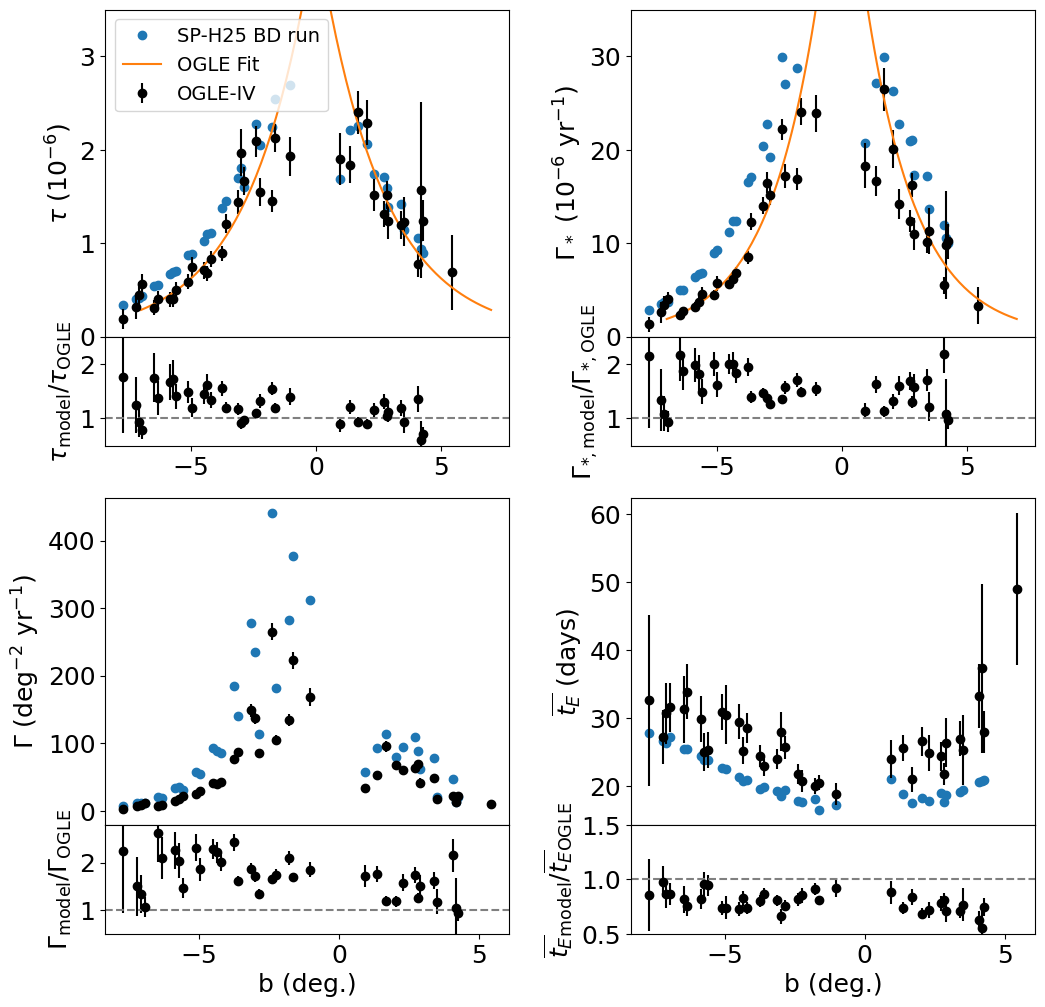

Saved Figure 12-style plot to: ogle_bdep_tElim_only_min001.pdf

Weighted mean ratios:
eventrate_area   = 1.615787018326645
eventrate_source = 1.4467187997647708e-06
avg_tau          = 1.1350968390333942
avg_t            = 0.7883557248493402


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import fetch_data

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
TAG = "min001"
RATES_FILE = Path(f"mulens_rates_ogle_0tE300_{TAG}.txt")
SUBFS_FILE = Path(f"subfs_inmap_{TAG}.csv")
FIG_OUT = Path(f"ogle_bdep_tElim_only_{TAG}.pdf")

if not RATES_FILE.exists():
    raise FileNotFoundError(f"Could not find rates file: {RATES_FILE}")
if not SUBFS_FILE.exists():
    raise FileNotFoundError(f"Could not find chip list file: {SUBFS_FILE}")

# ------------------------------------------------------------
# Load OGLE tables
# ------------------------------------------------------------
DATA_DIR = Path("data/apjsab426b")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019(
    location=str(DATA_DIR) + "/"
)

ogle_surfdens = ogle_surfdens.copy()
ogle_fields = ogle_fields.copy()
ogle_rates = ogle_rates.copy()

ogle_rates["RAdeg"] = ogle_fields["RAdeg"]
ogle_rates["DEdeg"] = ogle_fields["DEdeg"]

ogle_rates.sort_values("GLAT", inplace=True)
ogle_rates["in_lims"] = (
    (np.abs(ogle_rates["GLON"]) < 10)
    & (ogle_rates["GLAT"] < 5)
    & (ogle_rates["GLAT"] > -10)
)
ogle_rates["use_for_latdep"] = (
    (np.abs(ogle_rates["GLON"]) < 3)
    & (ogle_rates["Nevents"] > 1)
    & (np.abs(ogle_rates["GLAT"]) > 0.7)
)

# ------------------------------------------------------------
# Load saved generation outputs
# ------------------------------------------------------------
subfs_inmap = pd.read_csv(SUBFS_FILE, index_col=0)
chip_rates = pd.read_csv(RATES_FILE)

if len(subfs_inmap) != len(chip_rates):
    raise ValueError(
        f"Length mismatch: {SUBFS_FILE} has {len(subfs_inmap)} rows but "
        f"{RATES_FILE} has {len(chip_rates)} rows."
    )

# align chip_rates with the chip names from subfs_inmap
chip_rates.index = subfs_inmap.index

# ------------------------------------------------------------
# Average chip rates back onto OGLE fields
# Same logic as the notebook workflow
# ------------------------------------------------------------
sim_fields = ogle_fields[["GLON", "GLAT"]].copy()
props_list = ["eventrate_area", "eventrate_source", "avg_tau", "avg_t", "avg_logt"]

for idx in ogle_fields.index:
    chips = [(idx in idx_chip) for idx_chip in subfs_inmap.index]
    if np.sum(chips) > 16:
        for prop in props_list:
            sim_fields.loc[idx, prop] = np.mean(chip_rates.loc[chips, prop])

ogle_rates_sel = ogle_rates[ogle_rates["use_for_latdep"]].copy()
sp_dat = sim_fields.loc[ogle_rates_sel.index].copy()

print(f"Using {len(sp_dat)} plotted OGLE fields")
print(f"Using {len(subfs_inmap)} chip-level rates from {RATES_FILE}")

# ------------------------------------------------------------
# Figure 12-style plot
# ------------------------------------------------------------
def tau_fit(b):
    return 1.36 * np.exp(0.39 * (3 - np.abs(b)))

def rt_fit(b):
    return 13.4 * np.exp(0.49 * (3 - np.abs(b)))

b_pts = np.arange(-7, 7.0001, 0.1)

plt.rcParams.update({"font.size": 18})

fig = plt.figure(figsize=(12, 12))
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.12)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
gs_bottom = outer[1].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)

ax = [[None, None], [None, None], [None, None], [None, None]]
ax[0][0] = fig.add_subplot(gs_top[0, 0])
ax[1][0] = fig.add_subplot(gs_top[1, 0], sharex=ax[0][0])
ax[0][1] = fig.add_subplot(gs_top[0, 1])
ax[1][1] = fig.add_subplot(gs_top[1, 1], sharex=ax[0][1])
ax[2][0] = fig.add_subplot(gs_bottom[0, 0])
ax[3][0] = fig.add_subplot(gs_bottom[1, 0], sharex=ax[2][0])
ax[2][1] = fig.add_subplot(gs_bottom[0, 1])
ax[3][1] = fig.add_subplot(gs_bottom[1, 1], sharex=ax[2][1])

modlab = "SP-H25 BD run"
oglab = "OGLE-IV"

# Optical depth
ax[0][0].plot(sp_dat["GLAT"], sp_dat["avg_tau"] * 1e6, "o", label=modlab)
ax[0][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tau"], yerr=ogle_rates_sel["e_tau"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][0].plot(b_pts, tau_fit(b_pts), label="OGLE Fit")
ax[0][0].set_ylabel(r"$\tau$ (10$^{-6}$)")
ax[0][0].set_ylim(0, 3.5)
ax[0][0].legend(fontsize=14)

ax[1][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"]),
    yerr=np.array(ogle_rates_sel["e_tau"]) * np.array(sp_dat["avg_tau"]) * 1e6 / np.array(ogle_rates_sel["tau"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][0].set_ylabel(r"$\tau_{\rm model}/\tau_{\rm OGLE}$")
ax[1][0].axhline(1, color="gray", linestyle="--")
ax[1][0].set_ylim(0.5, 2.5)

# Event rate per star
ax[0][1].plot(sp_dat["GLAT"], sp_dat["eventrate_source"] * 1e6, "o", label=modlab)
ax[0][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam"], yerr=ogle_rates_sel["e_gam"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[0][1].plot(b_pts, rt_fit(b_pts), label="OGLE Fit")
ax[0][1].set_ylabel(r"$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)")
ax[0][1].set_ylim(0, 35)

ax[1][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"]),
    yerr=np.array(ogle_rates_sel["e_gam"]) * np.array(sp_dat["eventrate_source"]) * 1e6 / np.array(ogle_rates_sel["gam"])**2,
    linestyle="none", marker="o", c="k"
)
ax[1][1].set_ylabel(r"$\Gamma_{*,\rm model}/\Gamma_{*,\rm OGLE}$")
ax[1][1].axhline(1, color="gray", linestyle="--")
ax[1][1].set_ylim(0.5, 2.5)

# Event rate per area
ax[2][0].plot(sp_dat["GLAT"], sp_dat["eventrate_area"], "o", label=modlab)
ax[2][0].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["gam-deg2"], yerr=ogle_rates_sel["e_gam-deg2"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][0].set_ylabel(r"$\Gamma$ (deg$^{-2}$ yr$^{-1}$)")

ax[3][0].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"]),
    yerr=np.array(ogle_rates_sel["e_gam-deg2"]) * np.array(sp_dat["eventrate_area"]) / np.array(ogle_rates_sel["gam-deg2"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][0].set_ylabel(r"$\Gamma_{\rm model}/\Gamma_{\rm OGLE}$")
ax[3][0].axhline(1, color="gray", linestyle="--")
ax[3][0].set_ylim(0.5, 2.8)
ax[3][0].set_xlabel("b (deg.)")

# Mean timescale
ax[2][1].plot(sp_dat["GLAT"], sp_dat["avg_t"], "o", label=modlab)
ax[2][1].errorbar(
    ogle_rates_sel["GLAT"], ogle_rates_sel["tE-mean"], yerr=ogle_rates_sel["e_tE-mean"],
    linestyle="none", marker="o", c="k", label=oglab
)
ax[2][1].set_ylabel(r"$\overline{t_E}$ (days)")

ax[3][1].errorbar(
    ogle_rates_sel["GLAT"],
    np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"]),
    yerr=np.array(ogle_rates_sel["e_tE-mean"]) * np.array(sp_dat["avg_t"]) / np.array(ogle_rates_sel["tE-mean"])**2,
    linestyle="none", marker="o", c="k"
)
ax[3][1].set_ylabel(r"$\overline{t_E}_{\rm model}/\overline{t_E}_{\rm OGLE}$")
ax[3][1].axhline(1, color="gray", linestyle="--")
ax[3][1].set_ylim(0.5, 1.5)
ax[3][1].set_xlabel("b (deg.)")

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved Figure 12-style plot to: {FIG_OUT}")

# ------------------------------------------------------------
# Weighted summary ratios, same style as notebook
# ------------------------------------------------------------
def weighted_ratio(model_vals, obs_vals, obs_errs):
    ratio = np.array(model_vals) / np.array(obs_vals)
    ratio_err = np.array(obs_errs) * np.array(model_vals) / np.array(obs_vals)**2
    return np.average(ratio[:-1], weights=1 / ratio_err[:-1]**2)

print("\nWeighted mean ratios:")
print("eventrate_area   =", weighted_ratio(sp_dat["eventrate_area"],   ogle_rates_sel["gam-deg2"], ogle_rates_sel["e_gam-deg2"]))
print("eventrate_source =", weighted_ratio(sp_dat["eventrate_source"], ogle_rates_sel["gam"],      ogle_rates_sel["e_gam"]))
print("avg_tau          =", weighted_ratio(sp_dat["avg_tau"] * 1e6,   ogle_rates_sel["tau"],      ogle_rates_sel["e_tau"]))
print("avg_t            =", weighted_ratio(sp_dat["avg_t"],            ogle_rates_sel["tE-mean"],  ogle_rates_sel["e_tE-mean"]))

In [1]:
import pandas as pd

bd = pd.read_csv("mulens_rates_ogle_0tE300_min001.txt")
print(bd[["f_src", "f_lens"]].head())

print((bd["f_src"].str.contains("ogle_chips_min001/src")).all())
print((bd["f_lens"].str.contains("ogle_chips_min001/lens")).all())

                                               f_src  \
0  /System/Volumes/Data/mnt/g3/scratch/rileypatla...   
1  /System/Volumes/Data/mnt/g3/scratch/rileypatla...   
2  /System/Volumes/Data/mnt/g3/scratch/rileypatla...   
3  /System/Volumes/Data/mnt/g3/scratch/rileypatla...   
4  /System/Volumes/Data/mnt/g3/scratch/rileypatla...   

                                              f_lens  
0  /System/Volumes/Data/mnt/g3/scratch/rileypatla...  
1  /System/Volumes/Data/mnt/g3/scratch/rileypatla...  
2  /System/Volumes/Data/mnt/g3/scratch/rileypatla...  
3  /System/Volumes/Data/mnt/g3/scratch/rileypatla...  
4  /System/Volumes/Data/mnt/g3/scratch/rileypatla...  
True
True


In [5]:
import pandas as pd
import numpy as np

base = pd.read_csv("mulens_rates_ogle_0tE300.txt")
bd   = pd.read_csv("mulens_rates_ogle_0tE300_min001.txt")

cols = ["avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]

for c in cols:
    ratio = bd[c] / base[c]
    print("\n", c)
    print("  mean ratio   =", np.nanmean(ratio))
    print("  median ratio =", np.nanmedian(ratio))
    print("  max |Δ/old|  =", np.nanmax(np.abs((bd[c] - base[c]) / base[c])))


 avg_tau
  mean ratio   = 1.0239507421307839
  median ratio = 0.9949578216173617
  max |Δ/old|  = 20.883830892639377

 eventrate_source
  mean ratio   = 1.1433990223606003
  median ratio = 1.1221695105560117
  max |Δ/old|  = 16.821771963246963

 eventrate_area
  mean ratio   = 1.0605691878140402
  median ratio = 1.040725724083051
  max |Δ/old|  = 15.340661941785765

 avg_t
  mean ratio   = 0.8944586405836571
  median ratio = 0.884785955429817
  max |Δ/old|  = 6.617074778637082

 frac_lowmass
  mean ratio   = 4.271994183052336
  median ratio = 3.596031037872917
  max |Δ/old|  = 639.2081621724147


In [6]:
print("baseline frac_lowmass mean =", base["frac_lowmass"].mean())
print("min001   frac_lowmass mean =", bd["frac_lowmass"].mean())

baseline frac_lowmass mean = 0.06475728156027553
min001   frac_lowmass mean = 0.23237020132225036


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

bd_path = Path("mulens_rates_ogle_0tE300_min001.txt")
if not bd_path.exists():
    raise FileNotFoundError(f"Could not find {bd_path}")

# try a few likely places for the baseline file
candidates = [
    Path("mulens_rates_ogle_0tE300.txt"),
    Path("../mulens_rates_ogle_0tE300.txt"),
    Path("outputfiles/mulens_rates_ogle_0tE300.txt"),
]

base_path = None
for p in candidates:
    if p.exists():
        base_path = p
        break

if base_path is None:
    # broader search nearby
    hits = list(Path(".").glob("**/mulens_rates_ogle_0tE300.txt"))
    if hits:
        base_path = hits[0]

if base_path is None:
    raise FileNotFoundError(
        "Could not find baseline file mulens_rates_ogle_0tE300.txt anywhere nearby."
    )

print("baseline:", base_path.resolve())
print("bd run:  ", bd_path.resolve())

base = pd.read_csv(base_path)
bd   = pd.read_csv(bd_path)

# align on field_id if available
if "field_id" in base.columns and "field_id" in bd.columns:
    merged = base.merge(
        bd,
        on="field_id",
        suffixes=("_base", "_bd")
    )
else:
    raise ValueError("Expected field_id column in both files.")

cols = ["avg_tau", "eventrate_source", "eventrate_area", "avg_t", "frac_lowmass"]

summary = []
for c in cols:
    ratio = merged[f"{c}_bd"] / merged[f"{c}_base"]
    frac_change = (merged[f"{c}_bd"] - merged[f"{c}_base"]) / merged[f"{c}_base"]

    summary.append({
        "metric": c,
        "mean_ratio": np.nanmean(ratio),
        "median_ratio": np.nanmedian(ratio),
        "mean_frac_change": np.nanmean(frac_change),
        "median_frac_change": np.nanmedian(frac_change),
        "max_abs_frac_change": np.nanmax(np.abs(frac_change)),
    })

summary = pd.DataFrame(summary)
display(summary)

print("baseline frac_lowmass mean =", merged["frac_lowmass_base"].mean())
print("min001   frac_lowmass mean =", merged["frac_lowmass_bd"].mean())

baseline: /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/mulens_rates_ogle_0tE300.txt
bd run:   /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/mulens_rates_ogle_0tE300_min001.txt


ValueError: You are trying to merge on int64 and object columns. If you wish to proceed you should use pd.concat

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
BASE_FILE = Path("mulens_rates_ogle_0tE300.txt")
NEW_FILE  = Path("mulens_rates_ogle_0tE300_min001.txt")
FIG_OUT   = Path("bd_vs_baseline_ratios_vs_b.pdf")

if not BASE_FILE.exists():
    raise FileNotFoundError(f"Could not find baseline file: {BASE_FILE}")
if not NEW_FILE.exists():
    raise FileNotFoundError(f"Could not find new file: {NEW_FILE}")

# ------------------------------------------------------------
# Load and merge
# ------------------------------------------------------------
base = pd.read_csv(BASE_FILE)
new  = pd.read_csv(NEW_FILE)

merged = base.merge(
    new,
    on="field_id",
    suffixes=("_base", "_new")
)

# keep one set of coordinates
merged["b"] = merged["b_new"]
merged["l"] = merged["l_new"]

# sanity check
print(f"baseline rows: {len(base)}")
print(f"new rows:      {len(new)}")
print(f"matched rows:  {len(merged)}")

# ------------------------------------------------------------
# Ratios
# ------------------------------------------------------------
metrics = {
    "avg_tau": r"$\tau_{\rm min001}/\tau_{\rm base}$",
    "eventrate_source": r"$\Gamma_{*,{\rm min001}}/\Gamma_{*,{\rm base}}$",
    "eventrate_area": r"$\Gamma_{{\rm min001}}/\Gamma_{{\rm base}}$",
    "avg_t": r"$\bar{t}_{E,{\rm min001}}/\bar{t}_{E,{\rm base}}$",
}

for c in metrics:
    merged[f"{c}_ratio"] = merged[f"{c}_new"] / merged[f"{c}_base"]

# optional: low-mass ratio too
merged["frac_lowmass_ratio"] = merged["frac_lowmass_new"] / merged["frac_lowmass_base"]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

for ax, (c, ylabel) in zip(axes, metrics.items()):
    y = merged[f"{c}_ratio"].to_numpy()
    x = merged["b"].to_numpy()

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    ax.plot(x, y, "o", ms=4)
    ax.axhline(1.0, linestyle="--", color="gray")

    med = np.nanmedian(y)
    mean = np.nanmean(y)
    ax.axhline(med, linestyle=":", color="gray")
    ax.text(
        0.02, 0.97,
        f"median = {med:.3f}\nmean = {mean:.3f}",
        transform=ax.transAxes,
        ha="left", va="top", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_ylabel(ylabel)

axes[2].set_xlabel("b (deg.)")
axes[3].set_xlabel("b (deg.)")

fig.suptitle("Brown dwarf run vs baseline: chip-level ratios", y=0.98)
fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {FIG_OUT}")

# ------------------------------------------------------------
# Also print compact summaries
# ------------------------------------------------------------
print("\nSummary statistics:")
for c in metrics:
    y = merged[f"{c}_ratio"]
    print(f"{c:18s} mean={np.nanmean(y):.4f}  median={np.nanmedian(y):.4f}")

ValueError: You are trying to merge on int64 and object columns. If you wish to proceed you should use pd.concat

In [11]:
print(base["field_id"].dtype, new["field_id"].dtype)
print(base["field_id"].head())
print(new["field_id"].head())

int64 int64
0    0
1    1
2    2
3    3
4    4
Name: field_id, dtype: int64
Series([], Name: field_id, dtype: int64)


baseline rows: 3451
new rows:      3451
matched rows:  3451


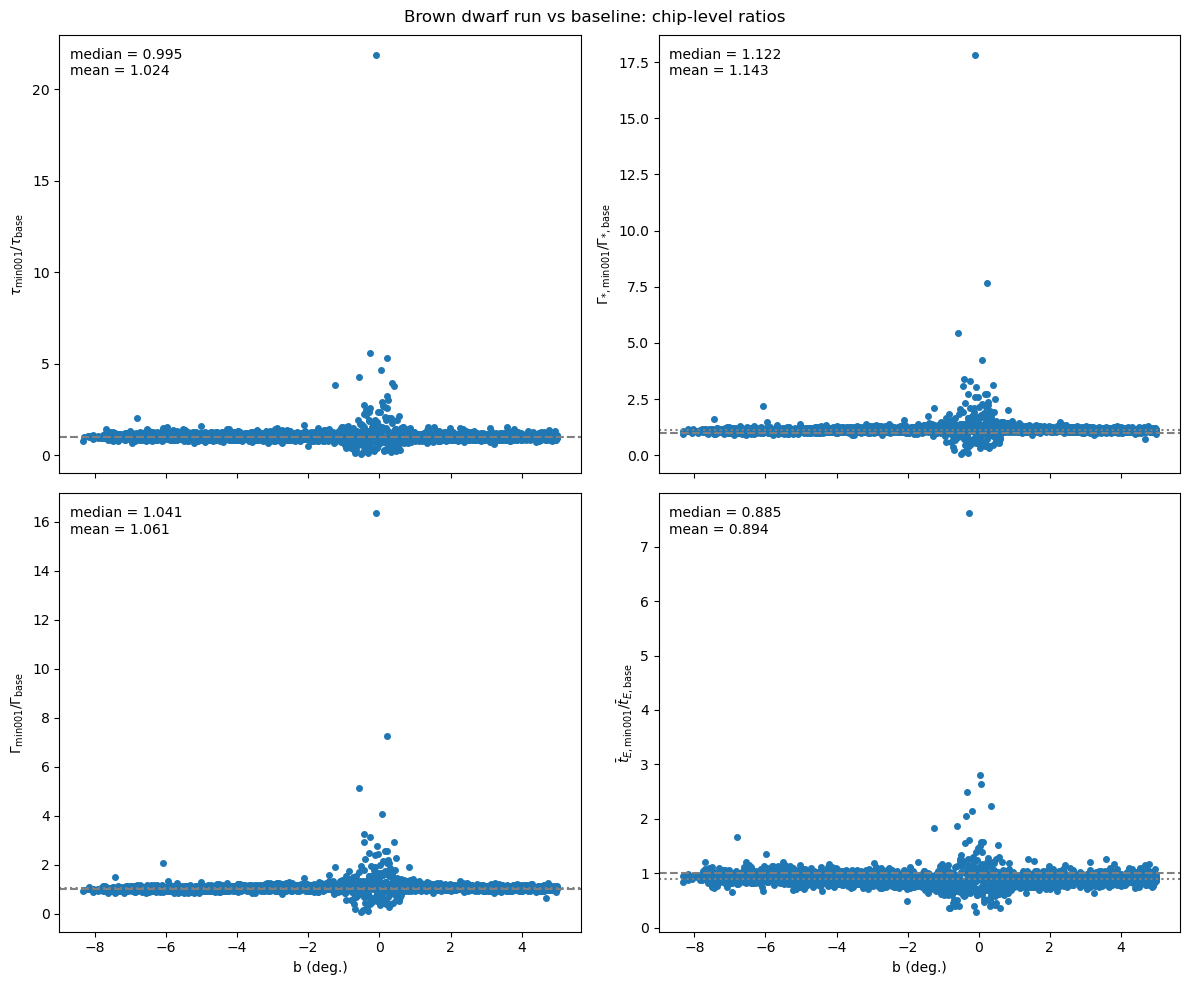

Saved figure to: bd_vs_baseline_ratios_vs_b.pdf

Summary statistics:
avg_tau            mean=1.0240  median=0.9950
eventrate_source   mean=1.1434  median=1.1222
eventrate_area     mean=1.0606  median=1.0407
avg_t              mean=0.8945  median=0.8848


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
BASE_FILE = Path("mulens_rates_ogle_0tE300.txt")
NEW_FILE  = Path("mulens_rates_ogle_0tE300_min001.txt")
FIG_OUT   = Path("bd_vs_baseline_ratios_vs_b.pdf")

base = pd.read_csv(BASE_FILE)
new  = pd.read_csv(NEW_FILE)

# ------------------------------------------------------------
# Match on sky position, not field_id
# ------------------------------------------------------------
for df in (base, new):
    df["l_key"] = df["l"].round(3)
    df["b_key"] = df["b"].round(3)

merged = base.merge(
    new,
    on=["l_key", "b_key"],
    suffixes=("_base", "_new"),
    how="inner",
    validate="one_to_one",
)

print(f"baseline rows: {len(base)}")
print(f"new rows:      {len(new)}")
print(f"matched rows:  {len(merged)}")

if len(merged) == 0:
    raise RuntimeError("No matched rows found on (l,b).")

# Use the new-run b for plotting
merged["b"] = merged["b_new"]

# ------------------------------------------------------------
# Ratios
# ------------------------------------------------------------
metrics = {
    "avg_tau": r"$\tau_{\rm min001}/\tau_{\rm base}$",
    "eventrate_source": r"$\Gamma_{*,{\rm min001}}/\Gamma_{*,{\rm base}}$",
    "eventrate_area": r"$\Gamma_{{\rm min001}}/\Gamma_{{\rm base}}$",
    "avg_t": r"$\bar{t}_{E,{\rm min001}}/\bar{t}_{E,{\rm base}}$",
}

for c in metrics:
    merged[f"{c}_ratio"] = merged[f"{c}_new"] / merged[f"{c}_base"]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

for ax, (c, ylabel) in zip(axes, metrics.items()):
    x = merged["b"].to_numpy()
    y = merged[f"{c}_ratio"].to_numpy()

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    ax.plot(x, y, "o", ms=4)
    ax.axhline(1.0, linestyle="--", color="gray")

    med = np.nanmedian(y)
    mean = np.nanmean(y)
    ax.axhline(med, linestyle=":", color="gray")

    ax.text(
        0.02, 0.97,
        f"median = {med:.3f}\nmean = {mean:.3f}",
        transform=ax.transAxes,
        ha="left", va="top", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_ylabel(ylabel)

axes[2].set_xlabel("b (deg.)")
axes[3].set_xlabel("b (deg.)")

fig.suptitle("Brown dwarf run vs baseline: chip-level ratios", y=0.98)
fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {FIG_OUT}")

# ------------------------------------------------------------
# Compact summaries
# ------------------------------------------------------------
print("\nSummary statistics:")
for c in metrics:
    y = merged[f"{c}_ratio"]
    print(f"{c:18s} mean={np.nanmean(y):.4f}  median={np.nanmedian(y):.4f}")

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
RATE_FILE = Path("mulens_rates_ogle_0tE300_min001.txt")

BD_MIN = 0.01   # Msun
BD_MAX = 0.08   # Msun

mass_candidates = [
    "mass", "iMass", "mass_current", "mass_lens", "m_ini", "mact", "Mass"
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def resolve_existing_paths(path_list):
    out = []
    missing = []
    for p in path_list:
        p = Path(str(p))
        if p.exists():
            out.append(p)
        else:
            missing.append(str(p))
    return out, missing

def find_hdf_key_and_masscol(example_file):
    with pd.HDFStore(example_file, "r") as store:
        for key in store.keys():
            try:
                df = store[key]
            except Exception:
                continue
            if isinstance(df, pd.DataFrame):
                for c in mass_candidates:
                    if c in df.columns:
                        return key, c
    raise RuntimeError(f"Could not find a usable mass column in {example_file}")

# ------------------------------------------------------------
# Load rate file and resolve lens files
# ------------------------------------------------------------
rates = pd.read_csv(RATE_FILE)
lens_files = sorted(set(rates["f_lens"].dropna().astype(str)))

lens_files, missing = resolve_existing_paths(lens_files)

print(f"rate file:          {RATE_FILE}")
print(f"lens paths in file: {len(set(rates['f_lens'].dropna().astype(str)))}")
print(f"resolved .h5 files: {len(lens_files)}")
print(f"missing .h5 files:  {len(missing)}")

if len(lens_files) == 0:
    raise FileNotFoundError("No min001 lens .h5 files could be found from f_lens paths.")

key, mass_col = find_hdf_key_and_masscol(lens_files[0])
print(f"HDF key:            {key}")
print(f"mass column:        {mass_col}")

# ------------------------------------------------------------
# Sum mass budget
# ------------------------------------------------------------
total_n = 0
total_mass = 0.0
bd_n = 0
bd_mass = 0.0

for fp in lens_files:
    df = pd.read_hdf(fp, key=key)
    m = pd.to_numeric(df[mass_col], errors="coerce").to_numpy()
    m = m[np.isfinite(m)]

    total_n += len(m)
    total_mass += m.sum()

    is_bd = (m >= BD_MIN) & (m < BD_MAX)
    bd_n += is_bd.sum()
    bd_mass += m[is_bd].sum()

non_bd_n = total_n - bd_n
non_bd_mass = total_mass - bd_mass

print("\nmin001 lens mass budget")
print("-----------------------")
print(f"total lenses                = {total_n}")
print(f"total lens mass [Msun]      = {total_mass:.6e}")
print(f"mean lens mass [Msun]       = {total_mass/total_n:.6e}")

print(f"\nbrown dwarf count           = {bd_n}")
print(f"brown dwarf number fraction = {bd_n/total_n:.6f}")
print(f"brown dwarf mass [Msun]     = {bd_mass:.6e}")
print(f"brown dwarf mass fraction   = {bd_mass/total_mass:.6f}")
print(f"mean BD mass [Msun]         = {bd_mass/bd_n:.6e}")

print(f"\nnon-BD count                = {non_bd_n}")
print(f"non-BD mass [Msun]          = {non_bd_mass:.6e}")
print(f"non-BD mass fraction        = {non_bd_mass/total_mass:.6f}")

rate file:          mulens_rates_ogle_0tE300_min001.txt
lens paths in file: 3451
resolved .h5 files: 3451
missing .h5 files:  0
HDF key:            /data
mass column:        iMass

min001 lens mass budget
-----------------------
total lenses                = 14292135
total lens mass [Msun]      = 5.382069e+06
mean lens mass [Msun]       = 3.765756e-01

brown dwarf count           = 5307965
brown dwarf number fraction = 0.371391
brown dwarf mass [Msun]     = 2.214213e+05
brown dwarf mass fraction   = 0.041141
mean BD mass [Msun]         = 4.171492e-02

non-BD count                = 8984170
non-BD mass [Msun]          = 5.160648e+06
non-BD mass fraction        = 0.958859


In [1]:
# Roman-extinction patch sanity/unit tests
# Run this after restarting the Jupyter kernel.

import os
import sys
import inspect
import tempfile
import importlib
import traceback
import warnings
import numpy as np
import pandas as pd
from types import SimpleNamespace

warnings.filterwarnings("ignore", message="Valid config keys have changed in V2")

# ============================================================
# 0. Force local repo imports
# ============================================================

LOCAL_POPSYCLE_REPO_CANDIDATES = [
    "/u/rileypatlak/code/PopSyCLE",
    os.path.abspath("PopSyCLE"),
    os.path.abspath("../PopSyCLE"),
]

LOCAL_SYNTHPOP_REPO_CANDIDATES = [
    "/u/rileypatlak/code/synthpop",
    os.path.abspath("synthpop"),
    os.path.abspath("../synthpop"),
]

def add_first_existing_repo(repo_candidates, label):
    for repo in repo_candidates:
        if os.path.isdir(repo):
            if repo not in sys.path:
                sys.path.insert(0, repo)
            print(f"Using local {label} repo: {repo}")
            return repo

    print(f"WARNING: Could not find local {label} repo from candidates:")
    for repo in repo_candidates:
        print("   ", repo)
    return None

LOCAL_POPSYCLE_REPO = add_first_existing_repo(LOCAL_POPSYCLE_REPO_CANDIDATES, "PopSyCLE")
LOCAL_SYNTHPOP_REPO = add_first_existing_repo(LOCAL_SYNTHPOP_REPO_CANDIDATES, "SynthPop")

importlib.invalidate_caches()

# ============================================================
# Helpers
# ============================================================

failures = []
warnings_list = []

def check(name, condition, details=""):
    if condition:
        print(f"PASS: {name}")
    else:
        msg = f"FAIL: {name}"
        if details:
            msg += f" | {details}"
        print(msg)
        failures.append(msg)

def warn_check(name, condition, details=""):
    if condition:
        print(f"PASS: {name}")
    else:
        msg = f"WARNING: {name}"
        if details:
            msg += f" | {details}"
        print(msg)
        warnings_list.append(msg)

# ============================================================
# 1. Import the edited modules
# ============================================================

from popsycle import synthetic as psyn

print("\nImported popsycle.synthetic from:")
print("   ", inspect.getfile(psyn))

from synthpop.modules.post_processing import popsycle_post_processing as ppp_mod

print("\nImported PopsyclePostProcessing module from:")
print("   ", inspect.getfile(ppp_mod))

expected_synthpop_tail = "synthpop/modules/post_processing/popsycle_post_processing.py"
actual_synthpop_path = inspect.getfile(ppp_mod).replace("\\", "/")

check(
    "Imported expected SynthPop popsycle_post_processing.py path",
    actual_synthpop_path.endswith(expected_synthpop_tail),
    f"got {actual_synthpop_path}"
)

# ============================================================
# 2. Confirm the patched API exists
# ============================================================

sig_calc_app = inspect.signature(psyn.calc_app_mag)
print("\ncalc_app_mag signature:", sig_calc_app)

check(
    "calc_app_mag accepts A_filter",
    "A_filter" in sig_calc_app.parameters,
    "Your notebook may still be importing the old synthetic.py."
)

check(
    "synthetic.py has _get_filter_extinction helper",
    hasattr(psyn, "_get_filter_extinction"),
    "This helper should have been added for Roman A_filter columns."
)

check(
    "photometric_system_dict includes roman",
    "roman" in psyn.photometric_system_dict,
    "phot_utils.py / imported photometric_system_dict does not include roman."
)

if "roman" in psyn.photometric_system_dict:
    check(
        "roman filter list includes f146",
        "f146" in psyn.photometric_system_dict["roman"],
        f"roman filters found: {psyn.photometric_system_dict['roman']}"
    )

check(
    "filt_dict includes roman_f146",
    "roman_f146" in psyn.filt_dict,
    "phot_utils.py / imported filt_dict does not include roman_f146."
)

# ============================================================
# 3. Unit test calc_app_mag numerically
# ============================================================

r = np.array([0.01, 1.0, 8.0])      # kpc
M = np.array([10.0, 12.0, 15.0])    # absolute mags
E = np.array([0.10, 0.20, 0.30])    # E(B-V)
f_i = 0.441                         # example Roman-ish extinction coefficient
A_filter = np.array([0.05, 0.25, 0.70])

expected_standard = M + 5.0 * np.log10(100.0 * r) + E * f_i
got_standard = psyn.calc_app_mag(r, M, E, f_i)

check(
    "calc_app_mag standard E*f path agrees with old formula",
    np.allclose(got_standard, expected_standard, rtol=0, atol=1e-12),
    f"got={got_standard}, expected={expected_standard}"
)

expected_roman = M + 5.0 * np.log10(100.0 * r) + A_filter
got_roman = psyn.calc_app_mag(r, M, E, f_i, A_filter=A_filter)

check(
    "calc_app_mag A_filter path uses direct per-filter extinction",
    np.allclose(got_roman, expected_roman, rtol=0, atol=1e-12),
    f"got={got_roman}, expected={expected_roman}"
)

check(
    "A_filter path differs from E*f path when A_filter != E*f",
    not np.allclose(got_roman, got_standard, rtol=0, atol=1e-12),
    "If this fails, A_filter is not actually being used."
)

# NaN behavior. For production science, silently accepting NaNs is dangerous.
try:
    got_nan = psyn.calc_app_mag(
        r,
        M,
        E,
        f_i,
        A_filter=np.array([0.05, np.nan, 0.70])
    )

    if np.any(np.isnan(got_nan)):
        warn_check(
            "NaN A_filter does not silently propagate",
            False,
            "calc_app_mag returned NaN apparent magnitudes. This is acceptable for debugging only if you catch/filter them later."
        )
    else:
        warn_check(
            "NaN A_filter does not silently fallback",
            False,
            "calc_app_mag appears to have replaced NaN A_filter values, probably using fallback behavior. For final science, make sure this is intentional."
        )

except Exception as e:
    print(f"PASS: NaN A_filter raises instead of silently passing ({type(e).__name__})")

# ============================================================
# 4. Unit test _get_filter_extinction on event-like Astropy Table
# ============================================================

from astropy.table import Table

event_tab = Table()
event_tab["A_roman_f146_S"] = np.array([0.40, 0.60])
event_tab["A_roman_f146_L"] = np.array([0.20, 0.30])
event_tab["roman_f146_S"] = np.array([15.0, 16.0])
event_tab["roman_f146_L"] = np.array([18.0, 19.0])
event_tab["exbv_S"] = np.array([1.0, 1.2])
event_tab["exbv_L"] = np.array([0.5, 0.7])
event_tab["rad_S"] = np.array([8.0, 7.0])
event_tab["rad_L"] = np.array([4.0, 3.0])

A_S = psyn._get_filter_extinction(event_tab, "roman", "f146", suffix="_S")
A_L = psyn._get_filter_extinction(event_tab, "roman", "f146", suffix="_L")
A_missing = psyn._get_filter_extinction(event_tab, "roman", "f184", suffix="_S")

check(
    "_get_filter_extinction finds source Roman extinction column",
    np.allclose(A_S, event_tab["A_roman_f146_S"]),
    f"got={A_S}"
)

check(
    "_get_filter_extinction finds lens Roman extinction column",
    np.allclose(A_L, event_tab["A_roman_f146_L"]),
    f"got={A_L}"
)

check(
    "_get_filter_extinction returns None for missing filter column",
    A_missing is None,
    f"got={A_missing}"
)

# ============================================================
# 5. Test PopsyclePostProcessing keeps and renames Roman extinction columns
#    This monkeypatches _bin_lb_hdf5 so no real HDF5 binning is needed.
# ============================================================

PopsyclePostProcessing = ppp_mod.PopsyclePostProcessing

check(
    "popsycle_post_processing filter_set_dict includes roman",
    "roman" in ppp_mod.filter_set_dict,
    f"filter_set_dict keys: {list(ppp_mod.filter_set_dict.keys())}"
)

needed_map = {
    "roman_f062": "R062",
    "roman_f087": "Z087",
    "roman_f106": "Y106",
    "roman_f129": "J129",
    "roman_f158": "H158",
    "roman_f146": "W146",
    "roman_f184": "F184",
    "roman_f213": "K213",
}

for k, v in needed_map.items():
    check(
        f"filter_matching_mist maps {k} -> {v}",
        ppp_mod.filter_matching_mist.get(k) == v,
        f"got {ppp_mod.filter_matching_mist.get(k)}"
    )

class DummyLogger:
    def info(self, msg):
        pass

class DummyExtinction:
    A_or_E_type = "E(B-V)"

class DummyModel:
    def __init__(self, outdir):
        self.l_deg = 0.0
        self.b_deg = 0.0
        self.solid_angle = 0.01
        self.solid_angle_unit = "deg"
        self.parms = SimpleNamespace(random_seed=123)
        self.populations = [SimpleNamespace(extinction=DummyExtinction())]
        self.outdir = outdir

    def get_filename(self, l_deg, b_deg, solid_angle):
        return os.path.join(self.outdir, "unit_test_field")

n = 4
df = pd.DataFrame({
    # SynthPop non-mag columns
    "l": np.zeros(n),
    "b": np.zeros(n),
    "Dist": np.array([1.0, 2.0, 4.0, 8.0]),
    "x": np.zeros(n),
    "y": np.zeros(n),
    "z": np.zeros(n),
    "vr_bc": np.zeros(n),
    "mul": np.zeros(n),
    "mub": np.zeros(n),
    "U": np.zeros(n),
    "V": np.zeros(n),
    "W": np.zeros(n),
    "iMass": np.ones(n),
    "Mass": np.ones(n),
    "log_L": np.zeros(n),
    "log_g": np.ones(n) * 4.5,
    "log_Teff": np.ones(n) * 3.5,
    "[Fe/H]": np.zeros(n),
    "age": np.ones(n) * 5.0,   # Gyr; code converts to log10(age*1e9)
    "pop": np.zeros(n),
    "phase": np.zeros(n),
    "E(B-V)": np.array([0.1, 0.2, 0.3, 0.4]),

    # Roman SynthPop/MIST mag columns after ConvertMistMags
    "R062": np.ones(n) * 20.0,
    "Z087": np.ones(n) * 19.5,
    "Y106": np.ones(n) * 19.0,
    "J129": np.ones(n) * 18.5,
    "H158": np.ones(n) * 18.0,
    "W146": np.ones(n) * 18.2,
    "F184": np.ones(n) * 17.7,
    "K213": np.ones(n) * 17.3,

    # Roman extinction columns from EstimateRomanExtinction
    "A_R062": np.array([1.20, 1.30, 1.40, 1.50]),
    "A_Z087": np.array([0.90, 1.00, 1.10, 1.20]),
    "A_Y106": np.array([0.70, 0.80, 0.90, 1.00]),
    "A_J129": np.array([0.50, 0.60, 0.70, 0.80]),
    "A_H158": np.array([0.35, 0.45, 0.55, 0.65]),
    "A_W146": np.array([0.42, 0.52, 0.62, 0.72]),
    "A_F184": np.array([0.25, 0.35, 0.45, 0.55]),
    "A_K213": np.array([0.18, 0.28, 0.38, 0.48]),

    # Should be dropped if keep-list logic is working
    "junk_column_should_be_dropped": np.arange(n),
})

captured = {}
orig_bin = ppp_mod._bin_lb_hdf5

def fake_bin_lb_hdf5(lat_bin_edges, long_bin_edges, obj_arr, output_root, companion_obj_arr=None):
    captured["lat_bin_edges"] = lat_bin_edges
    captured["long_bin_edges"] = long_bin_edges
    captured["columns"] = list(obj_arr.columns) if hasattr(obj_arr, "columns") else list(obj_arr.dtype.names)
    captured["obj_arr"] = obj_arr.copy()
    captured["output_root"] = output_root

try:
    with tempfile.TemporaryDirectory() as tmpdir:
        ppp_mod._bin_lb_hdf5 = fake_bin_lb_hdf5

        dummy_model = DummyModel(tmpdir)

        ppp = PopsyclePostProcessing(
            dummy_model,
            DummyLogger(),
            bin_edges_number=3,
            filter_sets=["roman"],
        )

        df_out = ppp.do_post_processing(df.copy())

finally:
    ppp_mod._bin_lb_hdf5 = orig_bin

cols = captured.get("columns", [])

check(
    "PopsyclePostProcessing reached HDF5 save step",
    len(cols) > 0,
    "No columns were captured by fake _bin_lb_hdf5."
)

for col in ["roman_f062", "roman_f146", "roman_f184", "roman_f213"]:
    check(
        f"saved columns include Roman mag {col}",
        col in cols,
        f"saved columns: {cols}"
    )

for col in ["A_roman_f062", "A_roman_f146", "A_roman_f184", "A_roman_f213"]:
    check(
        f"saved columns include Roman extinction {col}",
        col in cols,
        f"saved columns: {cols}"
    )

check(
    "raw SynthPop Roman extinction column A_W146 was renamed away",
    "A_W146" not in cols,
    "A_W146 should become A_roman_f146 before saving."
)

check(
    "junk column was dropped",
    "junk_column_should_be_dropped" not in cols,
    "Drop-list logic may not be working."
)

if "obj_arr" in captured and "A_roman_f146" in captured["obj_arr"]:
    check(
        "A_W146 values preserved as A_roman_f146",
        np.allclose(
            captured["obj_arr"]["A_roman_f146"].to_numpy(),
            df["A_W146"].to_numpy()
        ),
        f"got={captured['obj_arr']['A_roman_f146'].to_numpy()}, expected={df['A_W146'].to_numpy()}"
    )

if "obj_arr" in captured and "roman_f146" in captured["obj_arr"]:
    check(
        "W146 values preserved as roman_f146",
        np.allclose(
            captured["obj_arr"]["roman_f146"].to_numpy(),
            df["W146"].to_numpy()
        ),
        f"got={captured['obj_arr']['roman_f146'].to_numpy()}, expected={df['W146'].to_numpy()}"
    )

# ============================================================
# 6. Quick physical sanity checks on dummy Roman extinction columns
# ============================================================

if "obj_arr" in captured:
    out = captured["obj_arr"]

    if "A_roman_f062" in out and "A_roman_f184" in out:
        check(
            "dummy Roman extinction decreases from F062 to F184",
            np.all(out["A_roman_f062"].to_numpy() > out["A_roman_f184"].to_numpy()),
            "Shorter-wavelength extinction should generally be larger."
        )

    if "roman_f146" in out and "A_roman_f146" in out:
        m_no_ext = psyn.calc_app_mag(
            out["rad"].to_numpy(),
            out["roman_f146"].to_numpy(),
            np.zeros(len(out)),
            0.0,
        )

        m_with_roman = psyn.calc_app_mag(
            out["rad"].to_numpy(),
            out["roman_f146"].to_numpy(),
            out["exbv"].to_numpy(),
            0.441,
            A_filter=out["A_roman_f146"].to_numpy(),
        )

        check(
            "Roman A_filter makes stars fainter by A_roman_f146",
            np.allclose(
                m_with_roman - m_no_ext,
                out["A_roman_f146"].to_numpy()
            ),
            f"delta={m_with_roman - m_no_ext}, A={out['A_roman_f146'].to_numpy()}"
        )

# ============================================================
# 7. Final summary
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Failures: {len(failures)}")
print(f"Warnings: {len(warnings_list)}")

if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print(" -", w)

if failures:
    print("\nFailures:")
    for f in failures:
        print(" -", f)
    raise AssertionError("One or more Roman-extinction patch tests failed.")

print("\nAll hard tests passed.")

Using local PopSyCLE repo: /u/rileypatlak/code/PopSyCLE
Using local SynthPop repo: /u/rileypatlak/code/synthpop

Imported popsycle.synthetic from:
    /u/rileypatlak/code/PopSyCLE/popsycle/synthetic.py

Imported PopsyclePostProcessing module from:
    /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/modules/post_processing/popsycle_post_processing.py
PASS: Imported expected SynthPop popsycle_post_processing.py path

calc_app_mag signature: (r, M, E=None, f=None, A_filter=None, allow_fallback=False)
PASS: calc_app_mag accepts A_filter
PASS: synthetic.py has _get_filter_extinction helper
PASS: photometric_system_dict includes roman
PASS: roman filter list includes f146
PASS: filt_dict includes roman_f146
PASS: calc_app_mag standard E*f path agrees with old formula
PASS: calc_app_mag A_filter path uses direct per-filter extinction
PASS: A_filter path differs from E*f path when A_filter != E*f
PASS: NaN A_filter raises instead of silently passing (ValueError)
PASS: _g

In [1]:
from pathlib import Path
import re

# CHANGE THIS to the config you actually run
CONFIG_PATH = "/u/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf"

text = Path(CONFIG_PATH).read_text()
lines = text.splitlines()

print(f"Checking config:\n{CONFIG_PATH}\n")

# ------------------------------------------------------------
# 1. Check obsmag = False
# ------------------------------------------------------------
print("="*70)
print("1. Checking obsmag")
print("="*70)

obsmag_hits = []
for i, line in enumerate(lines, start=1):
    if "obsmag" in line:
        obsmag_hits.append((i, line))

if len(obsmag_hits) == 0:
    print("FAIL/WARNING: No obsmag setting found in this config.")
else:
    for i, line in obsmag_hits:
        print(f"line {i}: {line}")

    obsmag_false = any(
        re.search(r"obsmag\s*[:=]\s*(False|false)", line)
        for _, line in obsmag_hits
    )

    if obsmag_false:
        print("\nPASS: obsmag appears to be False.")
    else:
        print("\nFAIL: obsmag was found, but I do not see obsmag=False.")

# ------------------------------------------------------------
# 2. Check post-processing order
# ------------------------------------------------------------
print("\n" + "="*70)
print("2. Checking post-processing order")
print("="*70)

targets = ["ConvertMistMags", "EstimateRomanExtinction", "PopsyclePostProcessing"]

positions = {}
for target in targets:
    hits = [(i, line) for i, line in enumerate(lines, start=1) if target in line]
    positions[target] = hits

for target in targets:
    print(f"\n{target}:")
    if len(positions[target]) == 0:
        print("  NOT FOUND")
    else:
        for i, line in positions[target]:
            print(f"  line {i}: {line}")

if all(len(positions[t]) > 0 for t in targets):
    first_lines = {t: positions[t][0][0] for t in targets}

    correct_order = (
        first_lines["ConvertMistMags"]
        < first_lines["EstimateRomanExtinction"]
        < first_lines["PopsyclePostProcessing"]
    )

    if correct_order:
        print("\nPASS: post-processing order is ConvertMistMags -> EstimateRomanExtinction -> PopsyclePostProcessing.")
    else:
        print("\nFAIL: post-processing order is not correct.")
        print("Observed first occurrence line numbers:")
        print(first_lines)
else:
    print("\nFAIL/WARNING: Could not find all three post-processing modules.")

# ------------------------------------------------------------
# 3. Check PopsyclePostProcessing filter_sets
# ------------------------------------------------------------
print("\n" + "="*70)
print("3. Checking PopsyclePostProcessing filter_sets")
print("="*70)

filter_hits = []
for i, line in enumerate(lines, start=1):
    if "filter_sets" in line or "ubv" in line or "roman" in line:
        # print nearby only if it is plausibly related
        if "filter_sets" in line or "roman" in line:
            filter_hits.append((i, line))

if len(filter_hits) == 0:
    print("FAIL/WARNING: No filter_sets / roman lines found.")
else:
    for i, line in filter_hits:
        print(f"line {i}: {line}")

    has_filter_sets = "filter_sets" in text
    has_ubv = re.search(r'["\']ubv["\']', text) is not None
    has_roman = re.search(r'["\']roman["\']', text) is not None

    if has_filter_sets and has_ubv and has_roman:
        print("\nPASS: config appears to include filter_sets with both 'ubv' and 'roman'.")
    elif has_roman:
        print("\nWARNING: 'roman' appears in the config, but I cannot verify filter_sets=['ubv','roman'] from text search alone.")
    else:
        print("\nFAIL: I do not see 'roman' included in filter_sets.")

print("\nDone.")

Checking config:
/u/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf

1. Checking obsmag
line 105:     "obsmag": false,

FAIL: obsmag was found, but I do not see obsmag=False.

2. Checking post-processing order

ConvertMistMags:
  line 122:         "name": "ConvertMistMags",

EstimateRomanExtinction:
  line 136:         "name": "EstimateRomanExtinction",

PopsyclePostProcessing:
  line 140:         "name": "PopsyclePostProcessing",

PASS: post-processing order is ConvertMistMags -> EstimateRomanExtinction -> PopsyclePostProcessing.

3. Checking PopsyclePostProcessing filter_sets
line 141:         "filter_sets": [
line 143:           "roman"

PASS: config appears to include filter_sets with both 'ubv' and 'roman'.

Done.


In [2]:
import re
from pathlib import Path

CONFIG_PATH = "/u/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf"

text = Path(CONFIG_PATH).read_text()
lines = text.splitlines()

obsmag_hits = []
for i, line in enumerate(lines, start=1):
    if "obsmag" in line:
        obsmag_hits.append((i, line))

for i, line in obsmag_hits:
    print(f"line {i}: {line}")

obsmag_false = any(
    re.search(r'["\']?obsmag["\']?\s*[:=]\s*(False|false)', line)
    for _, line in obsmag_hits
)

if obsmag_false:
    print("\nPASS: obsmag appears to be False/false.")
else:
    print("\nFAIL: obsmag was found, but I do not see obsmag=False/false.")

line 105:     "obsmag": false,

PASS: obsmag appears to be False/false.


In [1]:
# ============================================================
# Tiny SynthPop -> PopSyCLE-format Roman extinction test run
# ============================================================

import os
import sys
import glob
import time
import shutil
import h5py
import importlib
import inspect
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
LOCAL_POPSYCLE_REPO = "/u/rileypatlak/code/PopSyCLE"
LOCAL_SYNTHPOP_REPO = "/u/rileypatlak/code/synthpop"

CONFIG_PATH = "/u/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf"

OUTPUT_DIR = "/u/rileypatlak/code/synthpop/outputfiles/roman_patch_test"
TEST_NAME = "roman_patch_test_min001"

# Tiny bulge-ish sightline for a fast sanity test.
# Increase SOLID_ANGLE only if the test produces too few objects.
L_DEG = 0.0
B_DEG = -1.0
SOLID_ANGLE = 5e-4   # deg^2

# Optional: try calc_events after the HDF5 is created.
# The main config/post-processing test does not require events.
RUN_CALC_EVENTS = False

# ------------------------------------------------------------
# Force local repo imports
# ------------------------------------------------------------
for repo in [LOCAL_POPSYCLE_REPO, LOCAL_SYNTHPOP_REPO]:
    if repo not in sys.path:
        sys.path.insert(0, repo)

importlib.invalidate_caches()

import synthpop
from popsycle import synthetic

print("Imported synthpop from:")
print("   ", inspect.getfile(synthpop))
print("Imported popsycle.synthetic from:")
print("   ", inspect.getfile(synthetic))

# ------------------------------------------------------------
# Clean previous tiny test output only
# ------------------------------------------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)

for fname in glob.glob(os.path.join(OUTPUT_DIR, f"{TEST_NAME}_l{L_DEG:.3f}_b{B_DEG:.3f}*")):
    print("Removing old test file:", fname)
    os.remove(fname)

# ------------------------------------------------------------
# Make and run SynthPop model
# ------------------------------------------------------------
print("\n" + "="*70)
print("Running tiny SynthPop Roman test")
print("="*70)
print("Config:", CONFIG_PATH)
print("Output:", OUTPUT_DIR)
print(f"Sightline: l={L_DEG}, b={B_DEG}, solid_angle={SOLID_ANGLE} deg^2")

t0 = time.time()

sp_mod = synthpop.SynthPop(
    CONFIG_PATH,
    output_location=OUTPUT_DIR,
    name_for_output=TEST_NAME,
    output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}",
    obsmag=False,
    overwrite=True,
)

# Some SynthPop workflows need this explicitly.
if hasattr(sp_mod, "init_populations"):
    sp_mod.init_populations()

df = sp_mod.process_location(
    L_DEG,
    B_DEG,
    solid_angle=SOLID_ANGLE,
    solid_angle_unit="deg^2",
    save_data=False,
)

dt = time.time() - t0
print(f"\nSynthPop tiny test finished in {dt:.1f} s")

# ------------------------------------------------------------
# Locate expected PopSyCLE HDF5 output
# ------------------------------------------------------------
expected_root = os.path.join(OUTPUT_DIR, f"{TEST_NAME}_l{L_DEG:.3f}_b{B_DEG:.3f}_psc")
expected_h5 = expected_root + ".h5"

print("\nExpected HDF5:")
print("   ", expected_h5)

if not os.path.exists(expected_h5):
    print("\nExpected HDF5 not found. Searching output directory...")
    candidates = glob.glob(os.path.join(OUTPUT_DIR, "*_psc.h5"))
    for c in candidates:
        print("   candidate:", c)
    raise FileNotFoundError(f"Could not find expected HDF5: {expected_h5}")

print("PASS: PopSyCLE-format HDF5 exists.")

# ------------------------------------------------------------
# Inspect HDF5 contents
# ------------------------------------------------------------
required_cols = [
    "rad",
    "glat",
    "glon",
    "mass",
    "zams_mass",
    "systemMass",
    "exbv",
    "obj_id",

    "ubv_I",

    "roman_f062",
    "roman_f087",
    "roman_f106",
    "roman_f129",
    "roman_f146",
    "roman_f158",
    "roman_f184",
    "roman_f213",

    "A_roman_f062",
    "A_roman_f087",
    "A_roman_f106",
    "A_roman_f129",
    "A_roman_f146",
    "A_roman_f158",
    "A_roman_f184",
    "A_roman_f213",
]

bad_raw_cols = [
    "A_R062",
    "A_Z087",
    "A_Y106",
    "A_J129",
    "A_W146",
    "A_H158",
    "A_F184",
    "A_K213",
]

all_cols = set()
data_keys = []
total_objects = 0
first_nonempty_key = None

with h5py.File(expected_h5, "r") as hf:
    keys = list(hf.keys())
    data_keys = [
        k for k in keys
        if ("bin_edges" not in k and "galaxyModel" not in k)
    ]

    print("\nHDF5 keys:")
    print(keys)

    for k in data_keys:
        dset = hf[k]
        total_objects += len(dset)

        if dset.dtype.names is not None:
            all_cols.update(dset.dtype.names)

        if len(dset) > 0 and first_nonempty_key is None:
            first_nonempty_key = k

print("\nNumber of object datasets:", len(data_keys))
print("Total objects in HDF5:", total_objects)
print("First nonempty dataset:", first_nonempty_key)

if total_objects == 0:
    raise RuntimeError(
        "The tiny test produced zero objects. Increase SOLID_ANGLE, e.g. to 1e-3 or 5e-3 deg^2."
    )

missing = [c for c in required_cols if c not in all_cols]
raw_present = [c for c in bad_raw_cols if c in all_cols]

print("\nColumn check:")
if missing:
    print("FAIL: Missing required columns:")
    for c in missing:
        print("   ", c)
else:
    print("PASS: All required Roman/PopSyCLE columns are present.")

if raw_present:
    print("FAIL: Raw SynthPop extinction columns still present; these should have been renamed:")
    for c in raw_present:
        print("   ", c)
else:
    print("PASS: Raw A_R062/A_W146-style columns were renamed away.")

if missing or raw_present:
    raise AssertionError("Column checks failed.")

# ------------------------------------------------------------
# Check Roman extinction values are finite and physically sensible
# ------------------------------------------------------------
def collect_col_from_h5(h5_path, col, max_rows=20000):
    vals = []
    with h5py.File(h5_path, "r") as hf:
        for k in hf.keys():
            if "bin_edges" in k or "galaxyModel" in k:
                continue

            dset = hf[k]
            if dset.dtype.names is None:
                continue

            if col not in dset.dtype.names:
                continue

            if len(dset) == 0:
                continue

            take = min(len(dset), max_rows - sum(len(v) for v in vals))
            vals.append(dset[col][:take])

            if sum(len(v) for v in vals) >= max_rows:
                break

    if len(vals) == 0:
        return np.array([])

    return np.concatenate(vals)

A062 = collect_col_from_h5(expected_h5, "A_roman_f062")
A146 = collect_col_from_h5(expected_h5, "A_roman_f146")
A184 = collect_col_from_h5(expected_h5, "A_roman_f184")
W146 = collect_col_from_h5(expected_h5, "roman_f146")
rad = collect_col_from_h5(expected_h5, "rad")

print("\nRoman extinction value checks:")

for name, arr in [
    ("A_roman_f062", A062),
    ("A_roman_f146", A146),
    ("A_roman_f184", A184),
    ("roman_f146", W146),
    ("rad", rad),
]:
    finite = np.isfinite(arr)
    print(f"{name}: N={len(arr)}, finite={np.sum(finite)}")
    if len(arr) > 0 and np.any(finite):
        print(
            f"   min/median/max = "
            f"{np.nanmin(arr):.4g}, {np.nanmedian(arr):.4g}, {np.nanmax(arr):.4g}"
        )

if len(A146) == 0 or np.sum(np.isfinite(A146)) == 0:
    raise AssertionError("A_roman_f146 exists as a column but contains no finite values.")

if np.nanmedian(A146) < 0:
    raise AssertionError("Median A_roman_f146 is negative, which is physically suspicious.")

if np.nanmedian(A062) <= np.nanmedian(A184):
    print(
        "WARNING: Median A_roman_f062 is not larger than A_roman_f184. "
        "This may be possible for pathological data, but inspect the extinction output."
    )
else:
    print("PASS: Median extinction decreases from F062 to F184 as expected.")

# ------------------------------------------------------------
# Optional calc_events smoke test
# ------------------------------------------------------------
if RUN_CALC_EVENTS:
    print("\n" + "="*70)
    print("Running optional tiny PopSyCLE calc_events smoke test")
    print("="*70)

    event_root = expected_root + "_events_test"

    for fname in glob.glob(event_root + "*"):
        print("Removing old event test file:", fname)
        os.remove(fname)

    synthetic.calc_events(
        hdf5_file=expected_h5,
        output_root2=event_root,
        radius_cut=2.0,
        obs_time=30,
        n_obs=3,
        theta_frac=2.0,
        blend_rad=0.65,
        n_proc=1,
        overwrite=True,
    )

    event_file = event_root + "_events.fits"
    blend_file = event_root + "_blends.fits"

    print("Event file exists:", os.path.exists(event_file), event_file)
    print("Blend file exists:", os.path.exists(blend_file), blend_file)
    print("Note: no-event output is acceptable for this tiny smoke test.")

print("\n" + "="*70)
print("TEST RUN SUMMARY")
print("="*70)
print("PASS: Tiny SynthPop Roman config run completed.")
print("PASS: PopSyCLE-format HDF5 was created.")
print("PASS: Roman magnitude columns are present.")
print("PASS: Roman extinction columns are present and renamed.")
print("PASS: A_roman_f146 has finite values.")
print("\nOutput HDF5:")
print(expected_h5)

/opt/mambaforge3/envs/astro-synthpop/lib/python3.11/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)
 12689 - Execution Date: 28-05-2026 13:55:11


################################ Settings #################################
 12691 - # reading default parameters from
 12693 - default_config_file =  /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 12696 - # read configuration from 
 12697 - config_file = '/u/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 12699 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "roman_patch_test_min001",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_an

Imported synthpop from:
    /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/__init__.py
Imported popsycle.synthetic from:
    /u/rileypatlak/code/PopSyCLE/popsycle/synthetic.py

Running tiny SynthPop Roman test
Config: /u/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults_min001.synthpop_conf
Output: /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test
Sightline: l=0.0, b=-1.0, solid_angle=0.0005 deg^2




# Population 1;  halo -----------------------------------------------------
 80360 - # Initialize Population 1 (halo) from 
 80362 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston2025/halo.popjson'


# Population 2;  nsd ------------------------------------------------------
 81892 - # Initialize Population 2 (nsd) from 
 81893 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston2025/nsd.popjson'


# Population 3;  thick_disk -----------------------------------------------
 84315 - # Initialize Population 3 (thick_disk) from 
 84318 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston2025/thick_disk.popjson'


# Population 4;  thin_disk_1 ----------------------------------------------
 85987 - # Initialize Population 4 (thin_disk_1) from 
 85989 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston20

  0%|          | 0/619870 [00:00<?, ?it/s]

 121306 - # From Generated Field:
 121309 - generated_stars = 619870
 121311 - generated_total_iMass = 236575.0331
 121359 - generated_total_eMass = 131773.1907
 121362 - det_mass_loss_corr = 0.5570
 121371 - # Done


# Population 1;  halo -----------------------------------------------------
 122365 - # From density profile (number density)
 122367 - expected_total_iMass = 265.4618
 122368 - expected_total_eMass = 145.7494
 122370 - average_iMass_per_star = 0.3762
 122372 - mass_loss_correction = 0.5490
 122373 - n_expected_stars = 705.6849
 122377 - # Determine velocities when position are generated 
 122534 - # From Generated Field:
 122536 - generated_stars = 742
 122537 - generated_total_iMass = 315.8443
 122547 - generated_total_eMass = 141.4127
 122549 - det_mass_loss_corr = 0.4477
 122552 - # Done


# Population 2;  nsd ------------------------------------------------------
 124149 - # From density profile (number density)
 124152 - expected_total_iMass = 5099.6845
 124154 - ex

estimating f062 extinction using ['f062_f087'] and order=4 function
estimating f087 extinction using ['f062_f087', 'f087_f106'] and order=4 function
estimating f106 extinction using ['f087_f106', 'f106_f129'] and order=4 function
estimating f129 extinction using ['f106_f129', 'f129_f158'] and order=4 function
estimating f158 extinction using ['f129_f158', 'f158_f184'] and order=4 function
estimating f184 extinction using ['f158_f184', 'f184_f213'] and order=4 function
estimating f213 extinction using ['f184_f213'] and order=4 function
estimating f146 extinction using ['f106_f129', 'f129_f158', 'f158_f184'] and order=4 function


 146279 - Beginning PopSyCLE postprocessing.
 146408 - Unused columns dropped
 146514 - E(B-V) calculated
 146522 - Parameter file written
 146524 - Basic columns renamed
 146533 - Age units converted
 146544 - Galactic longitude wrapped
 146549 - Added mbol via eval
 146553 - Added systemMass via eval
 146555 - Renamed mag cols
 146557 - Renamed Roman extinction cols
 146575 - Multiplicity and remnant columns added
 146577 - PopSyCLE dataframe modifications complete - binning and saving file
 151835 - PopSyCLE formatted output saved in /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_psc.h5
 151847 - ---------------------------------------------------------------




SynthPop tiny test finished in 139.2 s

Expected HDF5:
    /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_psc.h5
PASS: PopSyCLE-format HDF5 exists.

HDF5 keys:
['l0b0', 'l0b1', 'l1b0', 'l1b1', 'lat_bin_edges', 'long_bin_edges']

Number of object datasets: 4
Total objects in HDF5: 728864
First nonempty dataset: l0b0

Column check:
PASS: All required Roman/PopSyCLE columns are present.
PASS: Raw A_R062/A_W146-style columns were renamed away.

Roman extinction value checks:
A_roman_f062: N=20000, finite=9962
   min/median/max = 3.351, 7.168, 8.397
A_roman_f146: N=20000, finite=9962
   min/median/max = 0.8019, 1.639, 1.902
A_roman_f184: N=20000, finite=9962
   min/median/max = 0.3979, 0.8764, 1.135
roman_f146: N=20000, finite=9962
   min/median/max = -3.597, 9.312, 11.97
rad: N=20000, finite=20000
   min/median/max = 3.737, 7.479, 7.8
PASS: Median extinction decreases from F062 to F184 as expected.

TEST RUN SUMMARY
PASS: Tiny SynthPop Rom

In [2]:
import h5py
import numpy as np

h5_path = "/u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_psc.h5"

cols_to_check = ["roman_f146", "A_roman_f146", "mass", "zams_mass", "rem_id", "teff", "rad"]

rows = []
with h5py.File(h5_path, "r") as hf:
    for key in hf.keys():
        if "bin_edges" in key or "galaxyModel" in key:
            continue
        d = hf[key]
        if len(d) == 0:
            continue
        rows.append(d[:])

data = np.concatenate(rows)

finite_mag = np.isfinite(data["roman_f146"])
finite_A = np.isfinite(data["A_roman_f146"])
stellar = data["rem_id"] == 0
compact = data["rem_id"] > 0
bd_mass = (data["mass"] >= 0.01) & (data["mass"] < 0.08)

print("Total objects:", len(data))
print("Finite roman_f146:", np.sum(finite_mag), np.sum(finite_mag)/len(data))
print("Finite A_roman_f146:", np.sum(finite_A), np.sum(finite_A)/len(data))

print("\nBy object type:")
print("Stellar/rem_id==0:", np.sum(stellar))
print("  finite roman_f146:", np.sum(finite_mag & stellar), np.sum(finite_mag & stellar)/max(np.sum(stellar),1))
print("Compact/rem_id>0:", np.sum(compact))
print("  finite roman_f146:", np.sum(finite_mag & compact), np.sum(finite_mag & compact)/max(np.sum(compact),1))

print("\nBrown dwarf mass range:")
print("BD-mass objects:", np.sum(bd_mass))
print("  finite roman_f146:", np.sum(finite_mag & bd_mass), np.sum(finite_mag & bd_mass)/max(np.sum(bd_mass),1))
print("  finite A_roman_f146:", np.sum(finite_A & bd_mass), np.sum(finite_A & bd_mass)/max(np.sum(bd_mass),1))

print("\nObjects with finite mag but missing A_roman_f146:")
bad = finite_mag & ~finite_A
print("Count:", np.sum(bad))
if np.sum(bad) > 0:
    print("mass range:", np.nanmin(data['mass'][bad]), np.nanmax(data['mass'][bad]))
    print("teff range:", np.nanmin(data['teff'][bad]), np.nanmax(data['teff'][bad]))

Total objects: 728864
Finite roman_f146: 362782 0.4977362031874259
Finite A_roman_f146: 362782 0.4977362031874259

By object type:
Stellar/rem_id==0: 686781
  finite roman_f146: 362782 0.5282353472213122
Compact/rem_id>0: 42083
  finite roman_f146: 0 0.0

Brown dwarf mass range:
BD-mass objects: 270769
  finite roman_f146: 0 0.0
  finite A_roman_f146: 0 0.0

Objects with finite mag but missing A_roman_f146:
Count: 0


In [1]:
# Roman-extinction patch sanity/unit tests
# Run this after restarting the Jupyter kernel.

import os
import sys
import inspect
import tempfile
import importlib
import warnings
import numpy as np
import pandas as pd
from types import SimpleNamespace

warnings.filterwarnings("ignore", message="Valid config keys have changed in V2")

# ============================================================
# 0. Force local repo imports
# ============================================================

LOCAL_POPSYCLE_REPO_CANDIDATES = [
    "/u/rileypatlak/code/PopSyCLE",
    os.path.abspath("PopSyCLE"),
    os.path.abspath("../PopSyCLE"),
]

LOCAL_SYNTHPOP_REPO_CANDIDATES = [
    "/u/rileypatlak/code/synthpop",
    os.path.abspath("synthpop"),
    os.path.abspath("../synthpop"),
]

def add_first_existing_repo(repo_candidates, label):
    for repo in repo_candidates:
        if os.path.isdir(repo):
            if repo not in sys.path:
                sys.path.insert(0, repo)
            print(f"Using local {label} repo: {repo}")
            return repo

    print(f"WARNING: Could not find local {label} repo from candidates:")
    for repo in repo_candidates:
        print("   ", repo)
    return None

LOCAL_POPSYCLE_REPO = add_first_existing_repo(LOCAL_POPSYCLE_REPO_CANDIDATES, "PopSyCLE")
LOCAL_SYNTHPOP_REPO = add_first_existing_repo(LOCAL_SYNTHPOP_REPO_CANDIDATES, "SynthPop")

importlib.invalidate_caches()

# ============================================================
# Helpers
# ============================================================

failures = []
warnings_list = []

def check(name, condition, details=""):
    if condition:
        print(f"PASS: {name}")
    else:
        msg = f"FAIL: {name}"
        if details:
            msg += f" | {details}"
        print(msg)
        failures.append(msg)

def warn_check(name, condition, details=""):
    if condition:
        print(f"PASS: {name}")
    else:
        msg = f"WARNING: {name}"
        if details:
            msg += f" | {details}"
        print(msg)
        warnings_list.append(msg)

# ============================================================
# 1. Import the edited modules
# ============================================================

from popsycle import synthetic as psyn

print("\nImported popsycle.synthetic from:")
print("   ", inspect.getfile(psyn))

from synthpop.modules.post_processing import popsycle_post_processing as ppp_mod

print("\nImported PopsyclePostProcessing module from:")
print("   ", inspect.getfile(ppp_mod))

expected_synthpop_tail = "synthpop/modules/post_processing/popsycle_post_processing.py"
actual_synthpop_path = inspect.getfile(ppp_mod).replace("\\", "/")

check(
    "Imported expected SynthPop popsycle_post_processing.py path",
    actual_synthpop_path.endswith(expected_synthpop_tail),
    f"got {actual_synthpop_path}"
)

# ============================================================
# 2. Confirm the patched API exists
# ============================================================

sig_calc_app = inspect.signature(psyn.calc_app_mag)
print("\ncalc_app_mag signature:", sig_calc_app)

check(
    "calc_app_mag accepts A_filter",
    "A_filter" in sig_calc_app.parameters,
    "Your notebook may still be importing the old synthetic.py."
)

check(
    "calc_app_mag accepts allow_fallback",
    "allow_fallback" in sig_calc_app.parameters,
    "The safer dark-lens NaN version of calc_app_mag may not be loaded."
)

check(
    "synthetic.py has _get_filter_extinction helper",
    hasattr(psyn, "_get_filter_extinction"),
    "This helper should have been added for Roman A_filter columns."
)

check(
    "photometric_system_dict includes roman",
    "roman" in psyn.photometric_system_dict,
    "phot_utils.py / imported photometric_system_dict does not include roman."
)

if "roman" in psyn.photometric_system_dict:
    check(
        "roman filter list includes f146",
        "f146" in psyn.photometric_system_dict["roman"],
        f"roman filters found: {psyn.photometric_system_dict['roman']}"
    )

check(
    "filt_dict includes roman_f146",
    "roman_f146" in psyn.filt_dict,
    "phot_utils.py / imported filt_dict does not include roman_f146."
)

# ============================================================
# 3. Unit test calc_app_mag numerically
# ============================================================

r = np.array([0.01, 1.0, 8.0])      # kpc
M = np.array([10.0, 12.0, 15.0])    # absolute mags
E = np.array([0.10, 0.20, 0.30])    # E(B-V)
f_i = 0.441                         # example Roman-ish extinction coefficient
A_filter = np.array([0.05, 0.25, 0.70])

expected_standard = M + 5.0 * np.log10(100.0 * r) + E * f_i
got_standard = psyn.calc_app_mag(r, M, E, f_i)

check(
    "calc_app_mag standard E*f path agrees with old formula",
    np.allclose(got_standard, expected_standard, rtol=0, atol=1e-12),
    f"got={got_standard}, expected={expected_standard}"
)

expected_roman = M + 5.0 * np.log10(100.0 * r) + A_filter
got_roman = psyn.calc_app_mag(r, M, E, f_i, A_filter=A_filter)

check(
    "calc_app_mag A_filter path uses direct per-filter extinction",
    np.allclose(got_roman, expected_roman, rtol=0, atol=1e-12),
    f"got={got_roman}, expected={expected_roman}"
)

check(
    "A_filter path differs from E*f path when A_filter != E*f",
    not np.allclose(got_roman, got_standard, rtol=0, atol=1e-12),
    "If this fails, A_filter is not actually being used."
)

# ============================================================
# 4. NaN behavior for luminous stars vs. dark lenses
# ============================================================

# Case 1: finite magnitude + NaN A_filter should raise.
try:
    _ = psyn.calc_app_mag(
        r,
        M,
        E,
        f_i,
        A_filter=np.array([0.05, np.nan, 0.70])
    )
    check(
        "finite M with NaN A_filter raises",
        False,
        "This should raise because a luminous object is missing extinction."
    )
except ValueError:
    print("PASS: finite M with NaN A_filter raises")
except Exception as e:
    check(
        "finite M with NaN A_filter raises",
        False,
        f"raised wrong exception type {type(e).__name__}: {e}"
    )

# Case 2: NaN magnitude + NaN A_filter should return NaN, not crash.
# This is the intended behavior for dark/non-photometric lenses,
# including brown dwarfs if they are intentionally lens-only.
M_dark = np.array([10.0, np.nan, 15.0])
A_dark = np.array([0.05, np.nan, 0.70])

try:
    got_dark = psyn.calc_app_mag(
        r,
        M_dark,
        E,
        f_i,
        A_filter=A_dark
    )

    check(
        "dark/non-photometric object with NaN M and NaN A_filter is allowed",
        np.isnan(got_dark[1]) and np.isfinite(got_dark[0]) and np.isfinite(got_dark[2]),
        f"got={got_dark}"
    )

except Exception as e:
    check(
        "dark/non-photometric object with NaN M and NaN A_filter is allowed",
        False,
        f"raised {type(e).__name__}: {e}"
    )

# Case 3: allow_fallback=True should only be needed intentionally.
try:
    got_fallback = psyn.calc_app_mag(
        r,
        M,
        E,
        f_i,
        A_filter=np.array([0.05, np.nan, 0.70]),
        allow_fallback=True,
    )

    expected_fallback = M + 5.0 * np.log10(100.0 * r) + np.array([0.05, E[1] * f_i, 0.70])

    check(
        "allow_fallback=True replaces finite-M missing A_filter with E*f",
        np.allclose(got_fallback, expected_fallback, rtol=0, atol=1e-12),
        f"got={got_fallback}, expected={expected_fallback}"
    )

except Exception as e:
    check(
        "allow_fallback=True replaces finite-M missing A_filter with E*f",
        False,
        f"raised {type(e).__name__}: {e}"
    )

# ============================================================
# 5. Unit test _get_filter_extinction on event-like Astropy Table
# ============================================================

from astropy.table import Table

event_tab = Table()
event_tab["A_roman_f146_S"] = np.array([0.40, 0.60])
event_tab["A_roman_f146_L"] = np.array([0.20, 0.30])
event_tab["roman_f146_S"] = np.array([15.0, 16.0])
event_tab["roman_f146_L"] = np.array([18.0, 19.0])
event_tab["exbv_S"] = np.array([1.0, 1.2])
event_tab["exbv_L"] = np.array([0.5, 0.7])
event_tab["rad_S"] = np.array([8.0, 7.0])
event_tab["rad_L"] = np.array([4.0, 3.0])

A_S = psyn._get_filter_extinction(event_tab, "roman", "f146", suffix="_S")
A_L = psyn._get_filter_extinction(event_tab, "roman", "f146", suffix="_L")
A_missing = psyn._get_filter_extinction(event_tab, "roman", "f184", suffix="_S")

check(
    "_get_filter_extinction finds source Roman extinction column",
    np.allclose(A_S, event_tab["A_roman_f146_S"]),
    f"got={A_S}"
)

check(
    "_get_filter_extinction finds lens Roman extinction column",
    np.allclose(A_L, event_tab["A_roman_f146_L"]),
    f"got={A_L}"
)

check(
    "_get_filter_extinction returns None for missing filter column",
    A_missing is None,
    f"got={A_missing}"
)

# ============================================================
# 6. Test PopsyclePostProcessing keeps and renames Roman extinction columns
#    This monkeypatches _bin_lb_hdf5 so no real HDF5 binning is needed.
# ============================================================

PopsyclePostProcessing = ppp_mod.PopsyclePostProcessing

check(
    "popsycle_post_processing filter_set_dict includes roman",
    "roman" in ppp_mod.filter_set_dict,
    f"filter_set_dict keys: {list(ppp_mod.filter_set_dict.keys())}"
)

needed_map = {
    "roman_f062": "R062",
    "roman_f087": "Z087",
    "roman_f106": "Y106",
    "roman_f129": "J129",
    "roman_f158": "H158",
    "roman_f146": "W146",
    "roman_f184": "F184",
    "roman_f213": "K213",
}

for k, v in needed_map.items():
    check(
        f"filter_matching_mist maps {k} -> {v}",
        ppp_mod.filter_matching_mist.get(k) == v,
        f"got {ppp_mod.filter_matching_mist.get(k)}"
    )

class DummyLogger:
    def info(self, msg):
        pass

class DummyExtinction:
    A_or_E_type = "E(B-V)"

class DummyModel:
    def __init__(self, outdir):
        self.l_deg = 0.0
        self.b_deg = 0.0
        self.solid_angle = 0.01
        self.solid_angle_unit = "deg"
        self.parms = SimpleNamespace(random_seed=123)
        self.populations = [SimpleNamespace(extinction=DummyExtinction())]
        self.outdir = outdir

    def get_filename(self, l_deg, b_deg, solid_angle):
        return os.path.join(self.outdir, "unit_test_field")

n = 4
df = pd.DataFrame({
    # SynthPop non-mag columns
    "l": np.zeros(n),
    "b": np.zeros(n),
    "Dist": np.array([1.0, 2.0, 4.0, 8.0]),
    "x": np.zeros(n),
    "y": np.zeros(n),
    "z": np.zeros(n),
    "vr_bc": np.zeros(n),
    "mul": np.zeros(n),
    "mub": np.zeros(n),
    "U": np.zeros(n),
    "V": np.zeros(n),
    "W": np.zeros(n),
    "iMass": np.ones(n),
    "Mass": np.ones(n),
    "log_L": np.zeros(n),
    "log_g": np.ones(n) * 4.5,
    "log_Teff": np.ones(n) * 3.5,
    "[Fe/H]": np.zeros(n),
    "age": np.ones(n) * 5.0,   # Gyr; code converts to log10(age*1e9)
    "pop": np.zeros(n),
    "phase": np.zeros(n),
    "E(B-V)": np.array([0.1, 0.2, 0.3, 0.4]),

    # Roman SynthPop/MIST mag columns after ConvertMistMags
    "R062": np.ones(n) * 20.0,
    "Z087": np.ones(n) * 19.5,
    "Y106": np.ones(n) * 19.0,
    "J129": np.ones(n) * 18.5,
    "H158": np.ones(n) * 18.0,
    "W146": np.ones(n) * 18.2,
    "F184": np.ones(n) * 17.7,
    "K213": np.ones(n) * 17.3,

    # Roman extinction columns from EstimateRomanExtinction
    "A_R062": np.array([1.20, 1.30, 1.40, 1.50]),
    "A_Z087": np.array([0.90, 1.00, 1.10, 1.20]),
    "A_Y106": np.array([0.70, 0.80, 0.90, 1.00]),
    "A_J129": np.array([0.50, 0.60, 0.70, 0.80]),
    "A_H158": np.array([0.35, 0.45, 0.55, 0.65]),
    "A_W146": np.array([0.42, 0.52, 0.62, 0.72]),
    "A_F184": np.array([0.25, 0.35, 0.45, 0.55]),
    "A_K213": np.array([0.18, 0.28, 0.38, 0.48]),

    # Should be dropped if keep-list logic is working
    "junk_column_should_be_dropped": np.arange(n),
})

captured = {}
orig_bin = ppp_mod._bin_lb_hdf5

def fake_bin_lb_hdf5(lat_bin_edges, long_bin_edges, obj_arr, output_root, companion_obj_arr=None):
    captured["lat_bin_edges"] = lat_bin_edges
    captured["long_bin_edges"] = long_bin_edges
    captured["columns"] = list(obj_arr.columns) if hasattr(obj_arr, "columns") else list(obj_arr.dtype.names)
    captured["obj_arr"] = obj_arr.copy()
    captured["output_root"] = output_root

try:
    with tempfile.TemporaryDirectory() as tmpdir:
        ppp_mod._bin_lb_hdf5 = fake_bin_lb_hdf5

        dummy_model = DummyModel(tmpdir)

        ppp = PopsyclePostProcessing(
            dummy_model,
            DummyLogger(),
            bin_edges_number=3,
            filter_sets=["roman"],
        )

        df_out = ppp.do_post_processing(df.copy())

finally:
    ppp_mod._bin_lb_hdf5 = orig_bin

cols = captured.get("columns", [])

check(
    "PopsyclePostProcessing reached HDF5 save step",
    len(cols) > 0,
    "No columns were captured by fake _bin_lb_hdf5."
)

for col in ["roman_f062", "roman_f146", "roman_f184", "roman_f213"]:
    check(
        f"saved columns include Roman mag {col}",
        col in cols,
        f"saved columns: {cols}"
    )

for col in ["A_roman_f062", "A_roman_f146", "A_roman_f184", "A_roman_f213"]:
    check(
        f"saved columns include Roman extinction {col}",
        col in cols,
        f"saved columns: {cols}"
    )

check(
    "raw SynthPop Roman extinction column A_W146 was renamed away",
    "A_W146" not in cols,
    "A_W146 should become A_roman_f146 before saving."
)

check(
    "junk column was dropped",
    "junk_column_should_be_dropped" not in cols,
    "Drop-list logic may not be working."
)

if "obj_arr" in captured and "A_roman_f146" in captured["obj_arr"]:
    check(
        "A_W146 values preserved as A_roman_f146",
        np.allclose(
            captured["obj_arr"]["A_roman_f146"].to_numpy(),
            df["A_W146"].to_numpy()
        ),
        f"got={captured['obj_arr']['A_roman_f146'].to_numpy()}, expected={df['A_W146'].to_numpy()}"
    )

if "obj_arr" in captured and "roman_f146" in captured["obj_arr"]:
    check(
        "W146 values preserved as roman_f146",
        np.allclose(
            captured["obj_arr"]["roman_f146"].to_numpy(),
            df["W146"].to_numpy()
        ),
        f"got={captured['obj_arr']['roman_f146'].to_numpy()}, expected={df['W146'].to_numpy()}"
    )

# ============================================================
# 7. Quick physical sanity checks on dummy Roman extinction columns
# ============================================================

if "obj_arr" in captured:
    out = captured["obj_arr"]

    if "A_roman_f062" in out and "A_roman_f184" in out:
        check(
            "dummy Roman extinction decreases from F062 to F184",
            np.all(out["A_roman_f062"].to_numpy() > out["A_roman_f184"].to_numpy()),
            "Shorter-wavelength extinction should generally be larger."
        )

    if "roman_f146" in out and "A_roman_f146" in out:
        m_no_ext = psyn.calc_app_mag(
            out["rad"].to_numpy(),
            out["roman_f146"].to_numpy(),
            np.zeros(len(out)),
            0.0,
        )

        m_with_roman = psyn.calc_app_mag(
            out["rad"].to_numpy(),
            out["roman_f146"].to_numpy(),
            out["exbv"].to_numpy(),
            0.441,
            A_filter=out["A_roman_f146"].to_numpy(),
        )

        check(
            "Roman A_filter makes stars fainter by A_roman_f146",
            np.allclose(
                m_with_roman - m_no_ext,
                out["A_roman_f146"].to_numpy()
            ),
            f"delta={m_with_roman - m_no_ext}, A={out['A_roman_f146'].to_numpy()}"
        )

# ============================================================
# 8. Final summary
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Failures: {len(failures)}")
print(f"Warnings: {len(warnings_list)}")

if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print(" -", w)

if failures:
    print("\nFailures:")
    for f in failures:
        print(" -", f)
    raise AssertionError("One or more Roman-extinction patch tests failed.")

print("\nAll hard tests passed.")

Using local PopSyCLE repo: /u/rileypatlak/code/PopSyCLE
Using local SynthPop repo: /u/rileypatlak/code/synthpop

Imported popsycle.synthetic from:
    /u/rileypatlak/code/PopSyCLE/popsycle/synthetic.py

Imported PopsyclePostProcessing module from:
    /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/modules/post_processing/popsycle_post_processing.py
PASS: Imported expected SynthPop popsycle_post_processing.py path

calc_app_mag signature: (r, M, E=None, f=None, A_filter=None, allow_fallback=False)
PASS: calc_app_mag accepts A_filter
PASS: calc_app_mag accepts allow_fallback
PASS: synthetic.py has _get_filter_extinction helper
PASS: photometric_system_dict includes roman
PASS: roman filter list includes f146
PASS: filt_dict includes roman_f146
PASS: calc_app_mag standard E*f path agrees with old formula
PASS: calc_app_mag A_filter path uses direct per-filter extinction
PASS: A_filter path differs from E*f path when A_filter != E*f
PASS: finite M with NaN A_filter 

/u/rileypatlak/code/PopSyCLE/popsycle/synthetic.py:6490: UserWarning: 1 finite-magnitude objects used E*f fallback extinction.
  warn(f"{np.sum(bad)} finite-magnitude objects used E*f fallback extinction.")


In [2]:
# ============================================================
# PopSyCLE calc_events test for Roman/BD HDF5
# ============================================================

import os
import sys
import glob
import time
import inspect
import importlib
import numpy as np
from astropy.table import Table

# ------------------------------------------------------------
LOCAL_POPSYCLE_REPO = "/u/rileypatlak/code/PopSyCLE"

if LOCAL_POPSYCLE_REPO not in sys.path:
    sys.path.insert(0, LOCAL_POPSYCLE_REPO)

importlib.invalidate_caches()

from popsycle import synthetic

print("Imported popsycle.synthetic from:")
print("   ", inspect.getfile(synthetic))

h5_path = "/u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_psc.h5"

event_root = "/u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_calc_events_smoke"

print("\nInput HDF5:")
print("   ", h5_path)
print("Output root:")
print("   ", event_root)

if not os.path.exists(h5_path):
    raise FileNotFoundError(f"HDF5 file not found: {h5_path}")

for fname in glob.glob(event_root + "*"):
    print("Removing old file:", fname)
    os.remove(fname)


t0 = time.time()

synthetic.calc_events(
    hdf5_file=h5_path,
    output_root2=event_root,
    radius_cut=2.0,     # arcsec
    obs_time=1.0,       # days
    n_obs=1,
    theta_frac=2.0,
    blend_rad=0.65,     # arcsec
    n_proc=1,
    overwrite=True,
)

dt = time.time() - t0

print("\ncalc_events finished.")
print(f"Runtime: {dt:.1f} s")

events_file = event_root + "_events.fits"
blends_file = event_root + "_blends.fits"
log_file = event_root + "_calc_events.log"

print("\nExpected output files:")
print("events:", os.path.exists(events_file), events_file)
print("blends: ", os.path.exists(blends_file), blends_file)
print("log:    ", os.path.exists(log_file), log_file)

# ------------------------------------------------------------
# Inspect outputs if events were found
# ------------------------------------------------------------
if os.path.exists(events_file):
    events = Table.read(events_file)
    print("\nEvents table:")
    print("N_events:", len(events))
    print("Columns:", events.colnames[:20], "...")

    # Confirm Roman magnitude/extinction columns are present in event table.
    required_event_cols = [
        "roman_f146_L",
        "roman_f146_S",
        "A_roman_f146_L",
        "A_roman_f146_S",
        "mass_L",
        "mass_S",
        "theta_E",
        "u0",
        "mu_rel",
        "t0",
    ]

    missing = [c for c in required_event_cols if c not in events.colnames]

    if missing:
        print("\nFAIL: Missing expected event columns:")
        for c in missing:
            print("   ", c)
        raise AssertionError("calc_events output is missing expected Roman/PopSyCLE columns.")
    else:
        print("\nPASS: Event table contains Roman magnitude/extinction columns.")

    # Brown-dwarf lens diagnostic
    bd_lens = (events["mass_L"] >= 0.01) & (events["mass_L"] < 0.08)

    print("\nBrown-dwarf lens events:")
    print("N_BD_lens_events:", np.sum(bd_lens))

    if np.sum(bd_lens) > 0:
        print("BD lens mass min/median/max:",
              np.nanmin(events["mass_L"][bd_lens]),
              np.nanmedian(events["mass_L"][bd_lens]),
              np.nanmax(events["mass_L"][bd_lens]))

        print("BD lens roman_f146 finite:",
              np.sum(np.isfinite(events["roman_f146_L"][bd_lens])),
              "out of",
              np.sum(bd_lens))

        print("BD lens A_roman_f146 finite:",
              np.sum(np.isfinite(events["A_roman_f146_L"][bd_lens])),
              "out of",
              np.sum(bd_lens))

        print("\nExpected for dark BD lenses: roman_f146_L and A_roman_f146_L can be NaN.")

    # Source photometry diagnostic
    finite_source_mag = np.isfinite(events["roman_f146_S"])
    finite_source_A = np.isfinite(events["A_roman_f146_S"])

    print("\nSource Roman photometry:")
    print("finite roman_f146_S:", np.sum(finite_source_mag), "out of", len(events))
    print("finite A_roman_f146_S:", np.sum(finite_source_A), "out of", len(events))

    finite_source_missing_A = finite_source_mag & ~finite_source_A
    if np.any(finite_source_missing_A):
        raise AssertionError(
            f"{np.sum(finite_source_missing_A)} finite-magnitude sources are missing A_roman_f146_S."
        )
    else:
        print("PASS: No finite-magnitude sources are missing A_roman_f146_S.")

else:
    print("\nNo events file was created. This is acceptable for a tiny smoke test if the log says no events.")

# ------------------------------------------------------------
# Inspect blends if available
# ------------------------------------------------------------
if os.path.exists(blends_file):
    blends = Table.read(blends_file)
    print("\nBlends table:")
    print("N_blends:", len(blends))

    if len(blends) > 0:
        required_blend_cols = [
            "roman_f146_N",
            "A_roman_f146_N",
            "mass_N",
            "obj_id_L",
            "obj_id_S",
        ]

        missing_blend = [c for c in required_blend_cols if c not in blends.colnames]

        if missing_blend:
            print("\nFAIL: Missing expected blend columns:")
            for c in missing_blend:
                print("   ", c)
            raise AssertionError("blend output is missing expected Roman/PopSyCLE columns.")
        else:
            print("PASS: Blend table contains Roman neighbor magnitude/extinction columns.")

print("\n" + "="*70)
print("CALC_EVENTS SMOKE TEST SUMMARY")
print("="*70)
print("PASS: calc_events completed without crashing.")
print("If events were produced, Roman columns were inspected above.")

Imported popsycle.synthetic from:
    /u/rileypatlak/code/PopSyCLE/popsycle/synthetic.py

Input HDF5:
    /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_psc.h5
Output root:
    /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_calc_events_smoke
Working on loop ll, bb =  0 0
Candidate events detected:  22
calc_events runtime : 9.302745 s

calc_events finished.
Runtime: 9.4 s

Expected output files:
events: True /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_calc_events_smoke_events.fits
blends:  True /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_calc_events_smoke_blends.fits
log:     True /u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_calc_events_smoke_calc_events.log

Events table:
N_events: 22
Columns: ['glat_L', 'glon_L', 'rad_L', 'px_L', '

In [3]:
from astropy.table import Table
import numpy as np

events_file = "/u/rileypatlak/code/synthpop/outputfiles/roman_patch_test/roman_patch_test_min001_l0.000_b-1.000_calc_events_smoke_events.fits"

events = Table.read(events_file)

bd_lens = (events["mass_L"] >= 0.01) & (events["mass_L"] < 0.08)

def finite_count(col):
    arr = events[col][bd_lens]
    arr = np.ma.filled(arr, np.nan)
    return np.sum(np.isfinite(arr)), len(arr), arr

for col in ["roman_f146_L", "A_roman_f146_L", "mass_L", "rad_L", "mu_rel", "theta_E"]:
    nfin, ntot, arr = finite_count(col)
    print(col, "finite:", nfin, "out of", ntot)
    print("   values:", arr)

roman_f146_L finite: 0 out of 2
   values: roman_f146_L
------------
         nan
         nan
A_roman_f146_L finite: 0 out of 2
   values: A_roman_f146_L
--------------
           nan
           nan
mass_L finite: 2 out of 2
   values:        mass_L      
-------------------
0.06643075689649693
0.05800425435170486
rad_L finite: 2 out of 2
   values:       rad_L      
-----------------
8.026007143742149
8.202323205623427
mu_rel finite: 2 out of 2
   values:       mu_rel     
-----------------
5.013946288509119
6.679573131120157
theta_E finite: 2 out of 2
   values:       theta_E       
--------------------
 0.10850158226493657
0.039212665319468876


In [5]:
print("hello")

hello


In [1]:
import numpy as np
import pandas as pd

rates = pd.read_csv("mulens_rates_ogle_0tE300_min001.txt")

# total event weight per chip: Gamma_* times number of sources
w = rates["eventrate_source"] * rates["n_source"]

overall_frac_lowmass = np.sum(w * rates["frac_lowmass"]) / np.sum(w)

print("Current overall low-mass event fraction (< 0.1 Msun):")
print(f"{overall_frac_lowmass:.6f}")

print("\nDiagnostics:")
print(f"Unweighted mean frac_lowmass   = {rates['frac_lowmass'].mean():.6f}")
print(f"Median frac_lowmass            = {rates['frac_lowmass'].median():.6f}")
print(f"Weighted mean frac_lowmass     = {overall_frac_lowmass:.6f}")

Current overall low-mass event fraction (< 0.1 Msun):
0.231264

Diagnostics:
Unweighted mean frac_lowmass   = 0.232370
Median frac_lowmass            = 0.231147
Weighted mean frac_lowmass     = 0.231264


In [2]:
import inspect
from mulens_rates import microlensing_calculations as mc

src = inspect.getsource(mc)

for i, line in enumerate(src.splitlines(), start=1):
    if "frac_lowmass" in line or "0.1" in line:
        print(f"{i:4d}: {line}")

  24:                 'n_compact_obj':'', 'frac_compact_obj':'', 'frac_lowmass':'',
  52:                                                   'n_compact_obj','frac_compact_obj', 'frac_lowmass',
 144:     lens_lowmass = (np.array(lens['iMass'])<0.1).astype(int)
 217:     return_dict['frac_lowmass'] = np.sum(lens_lowmass[use_lens]*thetamu) / sum_thetamu    
 237: def prep_rates_for_gulls(rates_orig, chip_side=0.125, remove_dir_layers=0):


In [1]:
import importlib
from mulens_rates import microlensing_calculations as mc
importlib.reload(mc)
print(mc.__file__)

/u/rileypatlak/code/mulens_rates/mulens_rates/microlensing_calculations.py


In [4]:
import importlib
from pathlib import Path
import numpy as np
import pandas as pd
from mulens_rates import microlensing_calculations as mc

# make sure the edited module is loaded
importlib.reload(mc)
print("Using:", mc.__file__)

OLD_RATE_FILE = Path("mulens_rates_ogle_0tE300_min001.txt")
NEW_RATE_FILE = Path("mulens_rates_ogle_0tE300_min001_bdfrac.txt")

old = pd.read_csv(OLD_RATE_FILE)

rows = []
output_cols = None

for i, r in old.iterrows():
    print(f"{i+1}/{len(old)}  l={r['l']:.3f}  b={r['b']:.3f}")

    dat, output_cols = mc.mulens_stats(
        r["l"],
        r["b"],
        r["f_lens"],
        r["f_src"],
        field_id=r["field_id"],
        nsd=True,
        tE_range=[0, 300],
    )

    rows.append(dat)

new = pd.DataFrame(rows, columns=output_cols)
new.to_csv(NEW_RATE_FILE, index=False)

print(f"\nSaved: {NEW_RATE_FILE}")

# overall event-weighted BD event fraction
# note: frac_lowmass now means 0.01 <= M < 0.08 after your code edit
w = new["eventrate_source"] * new["n_source"]
overall_frac_bd = np.sum(w * new["frac_lowmass"]) / np.sum(w)

print("\nOverall brown dwarf event fraction (event-weighted):")
print(f"{overall_frac_bd:.6f}")

print("\nDiagnostics:")
print(f"Unweighted mean frac_lowmass = {new['frac_lowmass'].mean():.6f}")
print(f"Median frac_lowmass          = {new['frac_lowmass'].median():.6f}")
print(f"Weighted mean frac_lowmass   = {overall_frac_bd:.6f}")

Using: /u/rileypatlak/code/mulens_rates/mulens_rates/microlensing_calculations.py
1/3451  l=0.829  b=-1.666
2/3451  l=0.751  b=-1.534
3/3451  l=0.673  b=-1.401
4/3451  l=0.595  b=-1.269
5/3451  l=0.516  b=-1.137
6/3451  l=1.180  b=-1.630
7/3451  l=1.102  b=-1.497
8/3451  l=1.024  b=-1.365
9/3451  l=0.946  b=-1.232
10/3451  l=0.868  b=-1.099
11/3451  l=1.438  b=-1.479
12/3451  l=1.360  b=-1.346
13/3451  l=1.282  b=-1.213
14/3451  l=1.204  b=-1.080
15/3451  l=1.125  b=-0.947
16/3451  l=1.046  b=-0.814
17/3451  l=1.641  b=-1.190
18/3451  l=1.563  b=-1.056
19/3451  l=1.484  b=-0.923
20/3451  l=-0.233  b=-2.277
21/3451  l=-0.310  b=-2.144
22/3451  l=-0.388  b=-2.012
23/3451  l=-0.466  b=-1.880
24/3451  l=-0.545  b=-1.748
25/3451  l=-0.623  b=-1.616
26/3451  l=-0.702  b=-1.484
27/3451  l=0.119  b=-2.241
28/3451  l=0.041  b=-2.108
29/3451  l=-0.037  b=-1.975
30/3451  l=-0.115  b=-1.843
31/3451  l=-0.193  b=-1.710
32/3451  l=-0.272  b=-1.578
33/3451  l=-0.351  b=-1.445
34/3451  l=-0.430  b=-1.